# Synthetic NIAH-Style Counting v2

This notebook follows `notebooks/pipeline_v2_codex_prompt.md`.

The v2 experiment is intentionally narrower than the earlier ID/OOD notebooks:

- fixed prompt-body length;
- 64 noise-token types;
- 10 countable marker-token types `<A>` ... `<J>`;
- count range `1..10`;
- two separately trained small decoder-only Transformers:
  - `non_thinking`: directly predicts the final count after `<Ans>`;
  - `thinking`: generates an indexed trace after `<Think/>`, then predicts the final count;
- no ID/OOD split, no variable sequence length, no distractors, no steering.

The main comparison is whether explicit trace supervision helps the model learn sparse counting across low/mid/high count bins.
        

## Google Drive Login

在实验开始时挂载一次 Google Drive。后面的保存 cell 会复用该挂载，因此长实验结束时不会再次弹出登录流程。

In [ ]:
from pathlib import Path
import sys

DRIVE_RESULTS_ROOT = Path(
    "/content/drive/MyDrive/Colab_Notebooks/CoT_Counting/"
    "Synthetic_CoT_NiaH_Count/colab_results"
)
DRIVE_MOUNTED = False

def ensure_google_drive_mounted() -> bool:
    global DRIVE_MOUNTED
    if not ("google.colab" in sys.modules or Path("/content").exists()):
        print("Not in Colab; Google Drive mount skipped.")
        return False
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")
    DRIVE_RESULTS_ROOT.mkdir(parents=True, exist_ok=True)
    DRIVE_MOUNTED = True
    print("Google Drive ready:", DRIVE_RESULTS_ROOT)
    return True

ensure_google_drive_mounted()

In [48]:
from pathlib import Path
import json
import math
import os
import platform
import random
import shutil
import subprocess
import sys
from dataclasses import dataclass
from datetime import datetime
from typing import Any

REPO_URL = "https://github.com/Twist-Shan/Synthetic_CoT_NiaH_Count.git"
INSTALL_PACKAGE = True

IN_COLAB = "google.colab" in sys.modules or Path("/content").exists()
if IN_COLAB:
    repo_dir = Path("/content/Synthetic_CoT_NiaH_Count")
    if not (repo_dir / ".git").exists():
        subprocess.run(["git", "clone", REPO_URL, str(repo_dir)], check=True)
    os.chdir(repo_dir)

ROOT = Path.cwd()
if INSTALL_PACKAGE:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", "."], check=True)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn.functional as F
from IPython.display import Markdown, display
from sklearn.linear_model import LogisticRegression, RidgeCV
from sklearn.metrics import accuracy_score, mean_absolute_error, r2_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from torch.optim import AdamW
from tqdm.auto import tqdm
from transformers import GPT2Config, GPT2LMHeadModel

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 130

print("cwd:", ROOT)
print("python:", sys.executable)
print("platform:", platform.platform())
print("torch:", torch.__version__)
print("cuda:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))
        

cwd: /content/Synthetic_CoT_NiaH_Count
python: /usr/bin/python3
platform: Linux-6.6.122+-x86_64-with-glibc2.35
torch: 2.11.0+cu128
cuda: True
gpu: NVIDIA A100-SXM4-40GB


## Configuration

Use `PRESET = "debug"` to verify the whole pipeline quickly. Switch to `PRESET = "main"` for the full v2 experiment from the prompt.

The debug run still writes every required metric file and plot, but it is not scientifically meaningful.
        

In [49]:
PRESET = "main"  # "debug" or "main"
RUN_TRAINING = None
SKIP_TRAIN_IF_FINAL_CHECKPOINT_EXISTS = True
RUN_PROBES = True
RUN_ATTENTION = True
RUN_TESTS_FIRST = True
SAVE_CHECKPOINTS_AT_EVAL = True

CONFIGS = {
    "debug": {
        "seq_len": 64,
        "train_steps": 200,
        "batch_size": 32,
        "eval_every": 50,
        "log_every": 10,
        "test_examples_per_count": 20,
        "val_examples_per_count": 20,
        "probe_train_examples_per_count": 20,
        "probe_test_examples_per_count": 20,
        "attention_examples_per_count": 10,
        "seed": 1234,
    },
    "main": {
        "seq_len": 256,
        "train_steps": 10000,
        "batch_size": 128,
        "eval_every": 500,
        "log_every": 50,
        "test_examples_per_count": 1000,
        "val_examples_per_count": 200,
        "probe_train_examples_per_count": 500,
        "probe_test_examples_per_count": 500,
        "attention_examples_per_count": 100,
        "seed": 1234,
    },
}

cfg = dict(CONFIGS[PRESET])
cfg.update(
    {
        "noise_vocab_size": 64,
        "marker_vocab_size": 10,
        "min_count": 1,
        "max_count": 10,
        "n_layer": 4,
        "n_head": 4,
        "n_embd": 256,
        "n_positions": 320 if CONFIGS[PRESET]["seq_len"] <= 256 else CONFIGS[PRESET]["seq_len"] + 64,
        "learning_rate": 3.0e-4,
        "betas": (0.9, 0.95),
        "weight_decay": 0.1,
        "grad_clip_norm": 1.0,
        "warmup_steps": 500 if PRESET == "main" else 20,
        "device": "cuda" if torch.cuda.is_available() else "cpu",
    }
)

RUN_DIR = Path(f"runs/v2_marker_trace_seed{cfg['seed']}_{PRESET}")
PLOTS_DIR = RUN_DIR / "plots"
PROBES_DIR = RUN_DIR / "probes"
ATTENTION_DIR = RUN_DIR / "attention"
CHECKPOINT_DIR = RUN_DIR / "checkpoints"
for path in [RUN_DIR, PLOTS_DIR, PROBES_DIR, ATTENTION_DIR, CHECKPOINT_DIR]:
    path.mkdir(parents=True, exist_ok=True)

with (RUN_DIR / "config.json").open("w", encoding="utf-8") as f:
    json.dump(cfg, f, indent=2)

display(Markdown(f"**Run directory:** `{RUN_DIR}`"))
display(pd.DataFrame([cfg]).T.rename(columns={0: "value"}))
        

**Run directory:** `runs/v2_marker_trace_seed1234_main`

,value
seq_len,256
train_steps,10000
batch_size,128
eval_every,500
log_every,50
test_examples_per_count,1000
val_examples_per_count,200
probe_train_examples_per_count,500
probe_test_examples_per_count,500
attention_examples_per_count,100


In [50]:
if RUN_TESTS_FIRST:
    subprocess.run([sys.executable, "-m", "compileall", "-q", "src", "scripts"], check=True)
    subprocess.run([sys.executable, "-m", "pytest", "-q"], check=True)
        

## Core v2 Implementation

This cell defines the custom vocabulary, data generator, rendering logic, model construction, training loop, evaluation, and required plots.
        

In [51]:
SPECIAL_TOKENS = ["<PAD>", "<BOS>", "<EOS>", "<Ans>", "<Think/>", "</Think>"]
NOISE_TOKENS = [f"<N{i}>" for i in range(64)]
MARKER_TOKENS = [f"<{chr(ord('A') + i)}>" for i in range(10)]
NUMBER_TOKENS = [f"<{i}>" for i in range(1, 11)]
COUNT_BINS = {
    "low": {1, 2, 3},
    "mid": {4, 5, 6},
    "high": {7, 8, 9, 10},
}


def count_bin(count: int) -> str:
    for name, values in COUNT_BINS.items():
        if int(count) in values:
            return name
    raise ValueError(count)


@dataclass
class Vocab:
    token_to_id: dict[str, int]
    id_to_token: list[str]

    @classmethod
    def build(cls) -> "Vocab":
        tokens = SPECIAL_TOKENS + NOISE_TOKENS + MARKER_TOKENS + NUMBER_TOKENS
        return cls({tok: i for i, tok in enumerate(tokens)}, tokens)

    def encode(self, tokens: list[str]) -> list[int]:
        return [self.token_to_id[tok] for tok in tokens]

    def decode(self, ids: list[int]) -> list[str]:
        return [self.id_to_token[int(i)] for i in ids]

    @property
    def pad_id(self) -> int:
        return self.token_to_id["<PAD>"]

    @property
    def eos_id(self) -> int:
        return self.token_to_id["<EOS>"]

    @property
    def numeric_ids(self) -> list[int]:
        return [self.token_to_id[tok] for tok in NUMBER_TOKENS]

    def count_to_token(self, count: int) -> str:
        return f"<{int(count)}>"

    def token_to_count(self, token: str) -> int | None:
        if token.startswith("<") and token.endswith(">"):
            inner = token[1:-1]
            if inner.isdigit() and 1 <= int(inner) <= 10:
                return int(inner)
        return None

    def save(self, path: Path) -> None:
        with path.open("w", encoding="utf-8") as f:
            json.dump({"token_to_id": self.token_to_id, "id_to_token": self.id_to_token}, f, indent=2)


@dataclass
class BaseExample:
    seq_tokens: list[str]
    count: int
    needle_positions: list[int]
    needle_markers: list[str]
    seed: int | None = None


def validate_base_example(ex: BaseExample, seq_len: int) -> None:
    assert len(ex.seq_tokens) == seq_len
    assert 1 <= ex.count <= 10
    assert ex.count == len(ex.needle_positions) == len(ex.needle_markers)
    assert ex.needle_positions == sorted(ex.needle_positions)
    assert all(ex.seq_tokens[pos] == marker for pos, marker in zip(ex.needle_positions, ex.needle_markers))
    assert sum(tok in MARKER_TOKENS for tok in ex.seq_tokens) == ex.count


def sample_base_example(seq_len: int, rng: random.Random, *, count: int | None = None, seed: int | None = None) -> BaseExample:
    n = rng.randint(1, 10) if count is None else int(count)
    positions = sorted(rng.sample(range(seq_len), n))
    markers = [rng.choice(MARKER_TOKENS) for _ in range(n)]
    seq = [rng.choice(NOISE_TOKENS) for _ in range(seq_len)]
    for pos, marker in zip(positions, markers):
        seq[pos] = marker
    ex = BaseExample(seq, n, positions, markers, seed)
    validate_base_example(ex, seq_len)
    return ex


def sample_batch(seq_len: int, batch_size: int, rng: random.Random) -> list[BaseExample]:
    return [sample_base_example(seq_len, rng) for _ in range(batch_size)]


def balanced_examples(seq_len: int, examples_per_count: int, seed: int) -> list[BaseExample]:
    rng = random.Random(seed)
    examples = []
    for count in range(1, 11):
        for i in range(examples_per_count):
            examples.append(sample_base_example(seq_len, rng, count=count, seed=seed + 1000 * count + i))
    rng.shuffle(examples)
    return examples


def render_example(ex: BaseExample, model_type: str, vocab: Vocab) -> dict[str, Any]:
    if model_type == "non_thinking":
        tokens = ["<BOS>"] + ex.seq_tokens + ["<Ans>", vocab.count_to_token(ex.count), "<EOS>"]
        ans_pos = 1 + len(ex.seq_tokens)
        final_answer_pos = ans_pos + 1
        labels = [-100] * len(tokens)
        labels[final_answer_pos] = vocab.token_to_id[vocab.count_to_token(ex.count)]
        labels[final_answer_pos + 1] = vocab.token_to_id["<EOS>"]
        anchors = {
            "ans_token": ans_pos,
            "last_prompt_token": ans_pos - 1,
            "final_answer_pos": final_answer_pos,
            "prompt_start": 1,
            "prompt_end_exclusive": 1 + len(ex.seq_tokens),
        }
    elif model_type == "thinking":
        trace = []
        index_positions = []
        marker_positions = []
        pre_index_positions = []
        think_start_pos = 1 + len(ex.seq_tokens)
        pos = think_start_pos + 1
        prev_marker_pos = think_start_pos
        for k, marker in enumerate(ex.needle_markers, start=1):
            pre_index_positions.append(prev_marker_pos)
            trace.extend([vocab.count_to_token(k), marker])
            index_positions.append(pos)
            marker_positions.append(pos + 1)
            prev_marker_pos = pos + 1
            pos += 2
        tokens = ["<BOS>"] + ex.seq_tokens + ["<Think/>"] + trace + ["</Think>", "<Ans>", vocab.count_to_token(ex.count), "<EOS>"]
        think_end_pos = think_start_pos + 1 + len(trace)
        ans_pos = think_end_pos + 1
        final_answer_pos = ans_pos + 1
        labels = [-100] * len(tokens)
        for p in range(think_start_pos + 1, len(tokens)):
            labels[p] = vocab.token_to_id[tokens[p]]
        anchors = {
            "think_start": think_start_pos,
            "think_end": think_end_pos,
            "ans_token": ans_pos,
            "final_answer_pos": final_answer_pos,
            "prompt_start": 1,
            "prompt_end_exclusive": 1 + len(ex.seq_tokens),
            "index_positions": index_positions,
            "marker_positions": marker_positions,
            "pre_index_positions": pre_index_positions,
        }
    else:
        raise ValueError(model_type)
    return {
        "tokens": tokens,
        "input_ids": vocab.encode(tokens),
        "labels": labels,
        "anchors": anchors,
        "count": ex.count,
        "count_bin": count_bin(ex.count),
        "needle_positions": ex.needle_positions,
        "needle_markers": ex.needle_markers,
        "trace_tokens": [tok for k, marker in enumerate(ex.needle_markers, start=1) for tok in (vocab.count_to_token(k), marker)],
    }


def collate_rendered(rendered: list[dict[str, Any]], vocab: Vocab, device: str) -> dict[str, Any]:
    max_len = max(len(r["input_ids"]) for r in rendered)
    input_ids, labels, attention_mask = [], [], []
    for r in rendered:
        pad = max_len - len(r["input_ids"])
        input_ids.append(r["input_ids"] + [vocab.pad_id] * pad)
        labels.append(r["labels"] + [-100] * pad)
        attention_mask.append([1] * len(r["input_ids"]) + [0] * pad)
    return {
        "input_ids": torch.tensor(input_ids, dtype=torch.long, device=device),
        "labels": torch.tensor(labels, dtype=torch.long, device=device),
        "attention_mask": torch.tensor(attention_mask, dtype=torch.long, device=device),
        "rendered": rendered,
        "final_answer_pos": torch.tensor([r["anchors"]["final_answer_pos"] for r in rendered], dtype=torch.long, device=device),
        "counts": torch.tensor([r["count"] for r in rendered], dtype=torch.long, device=device),
    }


def build_model(vocab: Vocab, cfg: dict[str, Any]) -> GPT2LMHeadModel:
    model_cfg = GPT2Config(
        vocab_size=len(vocab.id_to_token),
        n_layer=cfg["n_layer"],
        n_head=cfg["n_head"],
        n_embd=cfg["n_embd"],
        n_positions=cfg["n_positions"],
        activation_function="gelu_new",
        resid_pdrop=0.0,
        embd_pdrop=0.0,
        attn_pdrop=0.0,
        bos_token_id=vocab.token_to_id["<BOS>"],
        eos_token_id=vocab.token_to_id["<EOS>"],
        pad_token_id=vocab.pad_id,
    )
    return GPT2LMHeadModel(model_cfg)


def set_lr(optimizer: torch.optim.Optimizer, step: int, cfg: dict[str, Any]) -> float:
    base = cfg["learning_rate"]
    warmup = max(int(cfg["warmup_steps"]), 1)
    total = max(int(cfg["train_steps"]), 1)
    if step <= warmup:
        lr = base * step / warmup
    else:
        progress = min(1.0, (step - warmup) / max(total - warmup, 1))
        lr = base * 0.5 * (1.0 + math.cos(math.pi * progress))
    for group in optimizer.param_groups:
        group["lr"] = lr
    return lr


def final_answer_loss_from_logits(logits: torch.Tensor, batch: dict[str, Any], vocab: Vocab) -> torch.Tensor:
    bsz = logits.shape[0]
    positions = batch["final_answer_pos"] - 1
    numeric_logits = logits[torch.arange(bsz, device=logits.device), positions][:, vocab.numeric_ids]
    targets = batch["counts"] - 1
    return F.cross_entropy(numeric_logits, targets)


def per_example_losses(logits: torch.Tensor, labels: torch.Tensor, batch: dict[str, Any], vocab: Vocab) -> tuple[np.ndarray, np.ndarray]:
    shift_logits = logits[:, :-1, :].contiguous()
    shift_labels = labels[:, 1:].contiguous()
    per_token = F.cross_entropy(
        shift_logits.view(-1, shift_logits.shape[-1]),
        shift_labels.view(-1),
        ignore_index=-100,
        reduction="none",
    ).view(shift_labels.shape)
    mask = (shift_labels != -100).float()
    completion = (per_token * mask).sum(dim=1) / mask.sum(dim=1).clamp_min(1.0)
    bsz = logits.shape[0]
    positions = batch["final_answer_pos"] - 1
    numeric_logits = logits[torch.arange(bsz, device=logits.device), positions][:, vocab.numeric_ids]
    targets = batch["counts"] - 1
    final = F.cross_entropy(numeric_logits, targets, reduction="none")
    return completion.detach().cpu().numpy(), final.detach().cpu().numpy()


def build_prefix(ex: BaseExample, model_type: str, vocab: Vocab) -> list[str]:
    if model_type == "non_thinking":
        return ["<BOS>"] + ex.seq_tokens + ["<Ans>"]
    if model_type == "thinking":
        return ["<BOS>"] + ex.seq_tokens + ["<Think/>"]
    raise ValueError(model_type)


@torch.no_grad()
def predict_non_thinking(model: GPT2LMHeadModel, examples: list[BaseExample], vocab: Vocab, cfg: dict[str, Any], batch_size: int = 128) -> list[dict[str, Any]]:
    model.eval()
    rows = []
    device = cfg["device"]
    for start in range(0, len(examples), batch_size):
        batch_examples = examples[start : start + batch_size]
        prefixes = [vocab.encode(build_prefix(ex, "non_thinking", vocab)) for ex in batch_examples]
        input_ids = torch.tensor(prefixes, dtype=torch.long, device=device)
        attention_mask = torch.ones_like(input_ids)
        logits = model(input_ids=input_ids, attention_mask=attention_mask).logits[:, -1, :]
        numeric_logits = logits[:, vocab.numeric_ids]
        pred = torch.argmax(numeric_logits, dim=-1).detach().cpu().numpy() + 1
        nll = F.cross_entropy(numeric_logits, torch.tensor([ex.count - 1 for ex in batch_examples], device=device), reduction="none").detach().cpu().numpy()
        for ex, pred_count, loss in zip(batch_examples, pred, nll):
            rows.append({"count": ex.count, "count_bin": count_bin(ex.count), "pred_count": int(pred_count), "invalid": False, "final_answer_loss": float(loss)})
    return rows


def parse_thinking_generation(generated_tokens: list[str], ex: BaseExample, vocab: Vocab) -> dict[str, Any]:
    ans_generated = "<Ans>" in generated_tokens
    pred_count = None
    invalid = True
    if ans_generated:
        ans_idx = generated_tokens.index("<Ans>")
        if ans_idx + 1 < len(generated_tokens):
            pred_count = vocab.token_to_count(generated_tokens[ans_idx + 1])
            invalid = pred_count is None
    trace_end = generated_tokens.index("</Think>") if "</Think>" in generated_tokens else len(generated_tokens)
    generated_trace = generated_tokens[:trace_end]
    expected_trace = [tok for k, marker in enumerate(ex.needle_markers, start=1) for tok in (vocab.count_to_token(k), marker)]
    expected_markers = [tok for tok in expected_trace if tok in MARKER_TOKENS]
    generated_markers = [tok for tok in generated_trace if tok in MARKER_TOKENS]
    marker_overlap = sum((pd.Series(generated_markers).value_counts() & pd.Series(expected_markers).value_counts()).fillna(0)) if expected_markers or generated_markers else 0
    marker_precision = 1.0 if not generated_markers and not expected_markers else float(marker_overlap) / max(len(generated_markers), 1)
    marker_recall = 1.0 if not expected_markers else float(marker_overlap) / len(expected_markers)
    expected_indices = expected_trace[0::2]
    correct_indices = 0
    for i, tok in enumerate(expected_indices):
        pos = 2 * i
        correct_indices += int(pos < len(generated_trace) and generated_trace[pos] == tok)
    trace_index_accuracy = correct_indices / max(len(expected_indices), 1)
    return {
        "pred_count": pred_count,
        "invalid": invalid,
        "ans_generated": ans_generated,
        "trace_exact_match": generated_trace == expected_trace,
        "trace_marker_precision": marker_precision,
        "trace_marker_recall": marker_recall,
        "trace_index_accuracy": trace_index_accuracy,
        "generated_tokens": generated_tokens,
    }


@torch.no_grad()
def predict_thinking(model: GPT2LMHeadModel, examples: list[BaseExample], vocab: Vocab, cfg: dict[str, Any], batch_size: int = 64) -> list[dict[str, Any]]:
    model.eval()
    rows = []
    device = cfg["device"]
    max_new = 2 * cfg["max_count"] + 4
    for start in tqdm(range(0, len(examples), batch_size), desc="thinking eval", leave=False):
        batch_examples = examples[start : start + batch_size]
        ids = torch.tensor([vocab.encode(build_prefix(ex, "thinking", vocab)) for ex in batch_examples], dtype=torch.long, device=device)
        prefix_len = ids.shape[1]
        finished = torch.zeros(len(batch_examples), dtype=torch.bool, device=device)
        for _ in range(max_new):
            attention_mask = torch.ones_like(ids)
            logits = model(input_ids=ids, attention_mask=attention_mask).logits[:, -1, :]
            next_ids = torch.argmax(logits, dim=-1)
            next_ids = torch.where(finished, torch.full_like(next_ids, vocab.pad_id), next_ids)
            ids = torch.cat([ids, next_ids[:, None]], dim=1)
            finished |= next_ids.eq(vocab.eos_id)
            if bool(finished.all()):
                break
        gen_ids = ids[:, prefix_len:].detach().cpu().tolist()
        for ex, gen in zip(batch_examples, gen_ids):
            toks = [tok for tok in vocab.decode(gen) if tok != "<PAD>"]
            parsed = parse_thinking_generation(toks, ex, vocab)
            rows.append({"count": ex.count, "count_bin": count_bin(ex.count), **parsed})
    return rows


@torch.no_grad()
def eval_losses(model: GPT2LMHeadModel, model_type: str, examples: list[BaseExample], vocab: Vocab, cfg: dict[str, Any], batch_size: int = 128) -> list[dict[str, Any]]:
    model.eval()
    rows = []
    device = cfg["device"]
    for start in range(0, len(examples), batch_size):
        batch_examples = examples[start : start + batch_size]
        rendered = [render_example(ex, model_type, vocab) for ex in batch_examples]
        batch = collate_rendered(rendered, vocab, device)
        logits = model(input_ids=batch["input_ids"], attention_mask=batch["attention_mask"]).logits
        completion, final = per_example_losses(logits, batch["labels"], batch, vocab)
        for ex, c_loss, f_loss in zip(batch_examples, completion, final):
            rows.append({"count": ex.count, "count_bin": count_bin(ex.count), "eval_completion_loss": float(c_loss), "eval_final_answer_loss": float(f_loss)})
    return rows


def summarize_eval(step: int, model_type: str, pred_rows: list[dict[str, Any]], loss_rows: list[dict[str, Any]]) -> tuple[pd.DataFrame, pd.DataFrame]:
    pred_df = pd.DataFrame(pred_rows)
    loss_df = pd.DataFrame(loss_rows)
    pred_df["correct"] = pred_df["pred_count"].fillna(-999).astype(int) == pred_df["count"].astype(int)
    pred_df["abs_error"] = (pred_df["pred_count"].fillna(-999).astype(int) - pred_df["count"].astype(int)).abs()
    pred_df["under"] = pred_df["pred_count"].fillna(999).astype(int) < pred_df["count"].astype(int)
    pred_df["over"] = pred_df["pred_count"].fillna(-999).astype(int) > pred_df["count"].astype(int)
    merged = pred_df.merge(loss_df, on=["count", "count_bin"], how="left")

    def agg(group: pd.DataFrame) -> pd.Series:
        out = {
            "step": step,
            "model_type": model_type,
            "accuracy": group["correct"].mean(),
            "n_examples": len(group),
            "invalid_rate": group.get("invalid", pd.Series(False, index=group.index)).mean(),
            "eval_completion_loss": group["eval_completion_loss"].mean(),
            "eval_final_answer_loss": group["eval_final_answer_loss"].mean(),
            "mae": group.loc[~group.get("invalid", pd.Series(False, index=group.index)), "abs_error"].mean(),
            "under_rate": group["under"].mean(),
            "over_rate": group["over"].mean(),
        }
        for name in ["trace_exact_match", "trace_marker_precision", "trace_marker_recall", "trace_index_accuracy"]:
            out[name + "_rate" if name == "trace_exact_match" else name] = group[name].mean() if name in group else np.nan
        return pd.Series(out)

    by_count = merged.groupby("count", as_index=True).apply(agg).reset_index()
    by_bin = merged.groupby("count_bin", as_index=True).apply(agg).reset_index()
    return by_count, by_bin


def save_checkpoint(models: dict[str, GPT2LMHeadModel], vocab: Vocab, step_name: str) -> None:
    ckpt = CHECKPOINT_DIR / step_name
    ckpt.mkdir(parents=True, exist_ok=True)
    for model_type, model in models.items():
        model.save_pretrained(ckpt / model_type)
    vocab.save(ckpt / "vocab.json")


def load_final_models(vocab: Vocab, cfg: dict[str, Any]) -> dict[str, GPT2LMHeadModel]:
    models = {}
    for model_type in ["non_thinking", "thinking"]:
        path = CHECKPOINT_DIR / "final" / model_type
        models[model_type] = GPT2LMHeadModel.from_pretrained(path).to(cfg["device"])
    return models


def evaluate_all(step: int, models: dict[str, GPT2LMHeadModel], test_examples: list[BaseExample], vocab: Vocab, cfg: dict[str, Any]) -> tuple[pd.DataFrame, pd.DataFrame]:
    all_count, all_bin = [], []
    for model_type, model in models.items():
        losses = eval_losses(model, model_type, test_examples, vocab, cfg)
        if model_type == "non_thinking":
            preds = predict_non_thinking(model, test_examples, vocab, cfg)
        else:
            preds = predict_thinking(model, test_examples, vocab, cfg)
        by_count, by_bin = summarize_eval(step, model_type, preds, losses)
        all_count.append(by_count)
        all_bin.append(by_bin)
    return pd.concat(all_count, ignore_index=True), pd.concat(all_bin, ignore_index=True)


def plot_required(run_dir: Path) -> None:
    plots = run_dir / "plots"
    train = pd.read_csv(run_dir / "metrics_train.csv")
    by_count = pd.read_csv(run_dir / "metrics_eval_by_count.csv")
    by_bin = pd.read_csv(run_dir / "metrics_eval_by_bin.csv")

    plt.figure(figsize=(9, 4.5))
    sns.lineplot(data=train, x="step", y="train_completion_loss", hue="model_type")
    sns.lineplot(data=train, x="step", y="train_final_answer_loss", hue="model_type", style="model_type", dashes=True, legend=False)
    plt.title("Training losses; completion loss is longer for thinking")
    plt.xlabel("training step")
    plt.ylabel("loss")
    plt.tight_layout()
    plt.savefig(plots / "train_loss_vs_step.png", bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(8, 4))
    sns.lineplot(data=by_count.groupby(["step", "model_type"], as_index=False)["eval_final_answer_loss"].mean(), x="step", y="eval_final_answer_loss", hue="model_type", marker="o")
    plt.title("Test final-answer loss over steps")
    plt.xlabel("training step")
    plt.ylabel("final-answer cross-entropy")
    plt.tight_layout()
    plt.savefig(plots / "eval_final_answer_loss_vs_step.png", bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(9, 4.5))
    sns.lineplot(data=by_bin, x="step", y="accuracy", hue="model_type", style="count_bin", marker="o")
    plt.ylim(-0.03, 1.03)
    plt.title("Test exact-count accuracy by count bin")
    plt.xlabel("training step")
    plt.ylabel("accuracy")
    plt.tight_layout()
    plt.savefig(plots / "eval_accuracy_by_bin_vs_step.png", bbox_inches="tight")
    plt.show()

    final_step = by_count["step"].max()
    final = by_count[by_count["step"] == final_step]
    plt.figure(figsize=(8, 4))
    sns.lineplot(data=final, x="count", y="accuracy", hue="model_type", marker="o")
    plt.ylim(-0.03, 1.03)
    plt.xticks(range(1, 11))
    plt.title(f"Final checkpoint accuracy by exact count (step {final_step})")
    plt.xlabel("gold count")
    plt.ylabel("accuracy")
    plt.tight_layout()
    plt.savefig(plots / "final_accuracy_by_count.png", bbox_inches="tight")
    plt.show()

    for model_type in ["non_thinking", "thinking"]:
        mat = by_count[by_count["model_type"] == model_type].pivot(index="count", columns="step", values="accuracy").sort_index()
        plt.figure(figsize=(8, 4.5))
        sns.heatmap(mat, vmin=0, vmax=1, cmap="viridis", annot=PRESET == "debug", fmt=".2f")
        plt.title(f"Accuracy heatmap: {model_type}")
        plt.xlabel("training step")
        plt.ylabel("gold count")
        plt.tight_layout()
        plt.savefig(plots / f"accuracy_heatmap_by_count_and_step_{model_type}.png", bbox_inches="tight")
        plt.show()
        

## Train and Evaluate

The training loop updates the two models on the same sampled base examples at every step, but with different renderings and label masks.
        

Loading existing final checkpoints.

Loading weights:   0%|          | 0/52 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/52 [00:00<?, ?it/s]

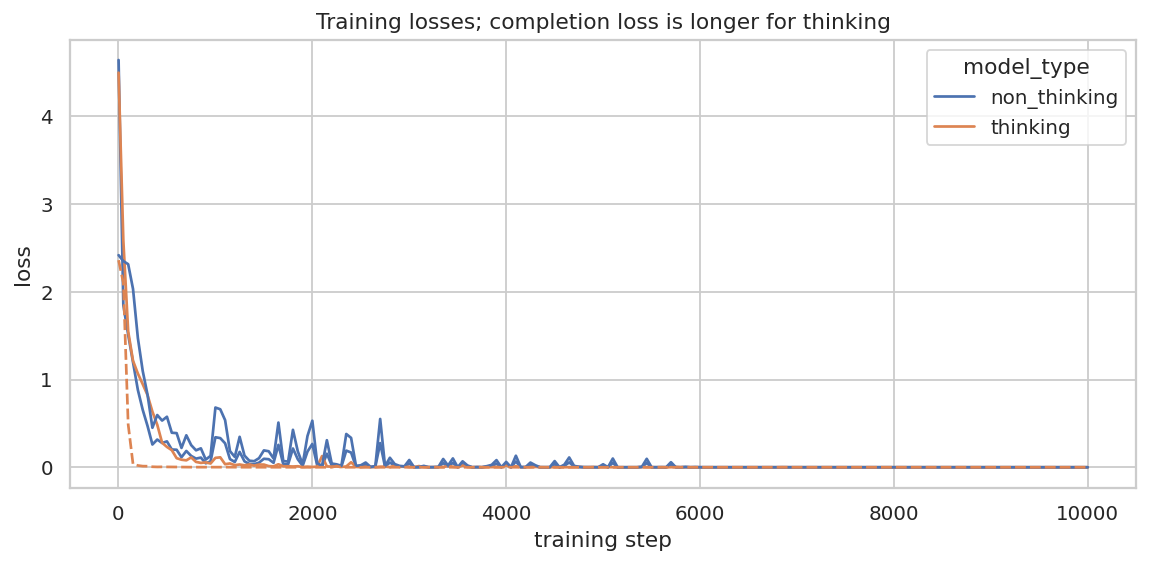

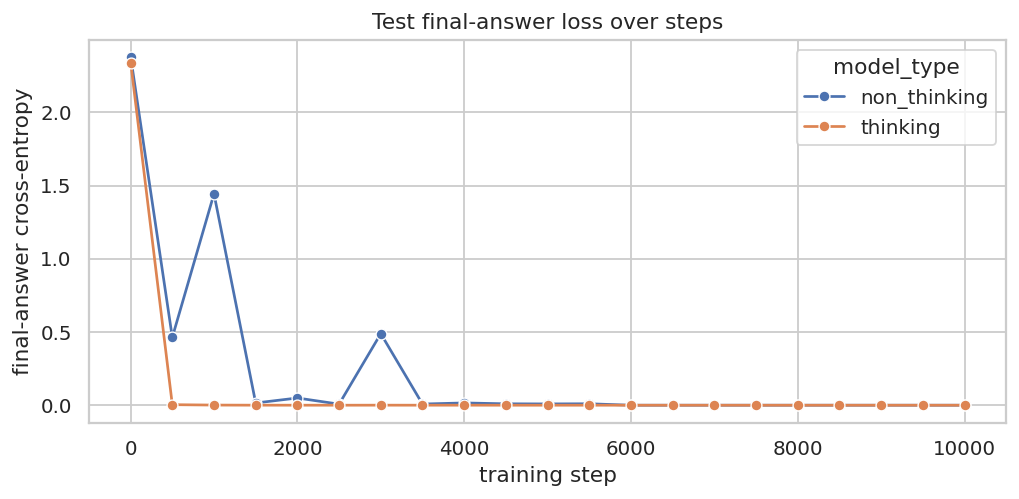

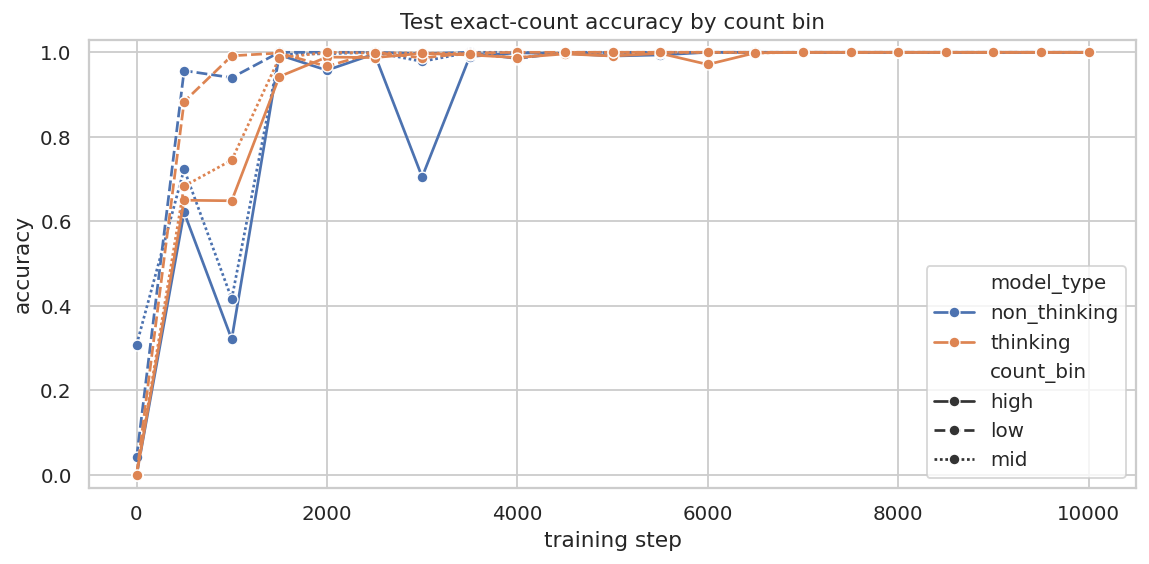

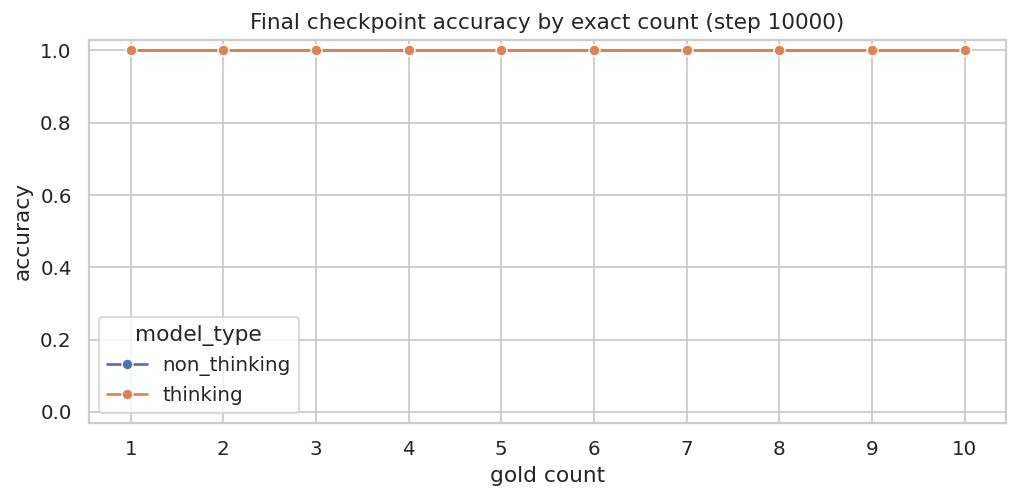

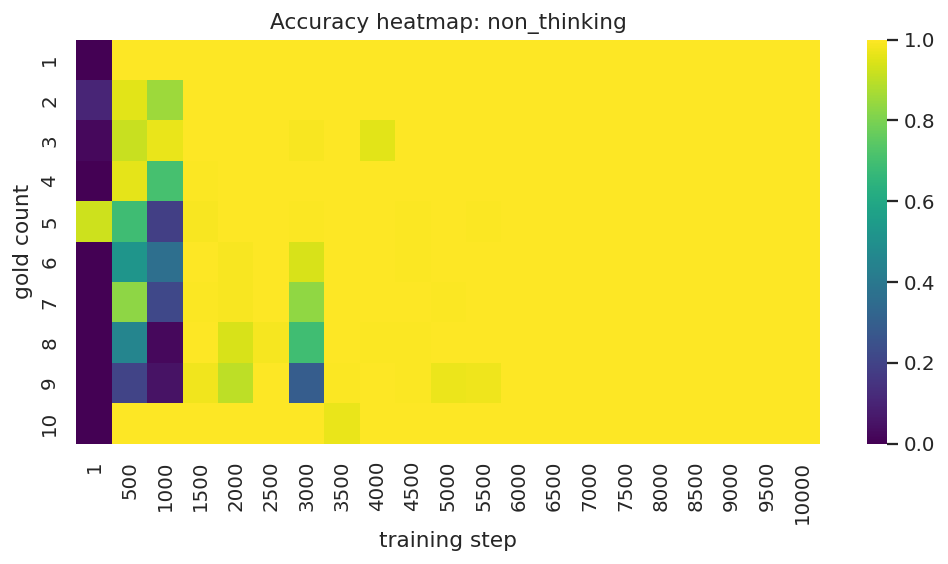

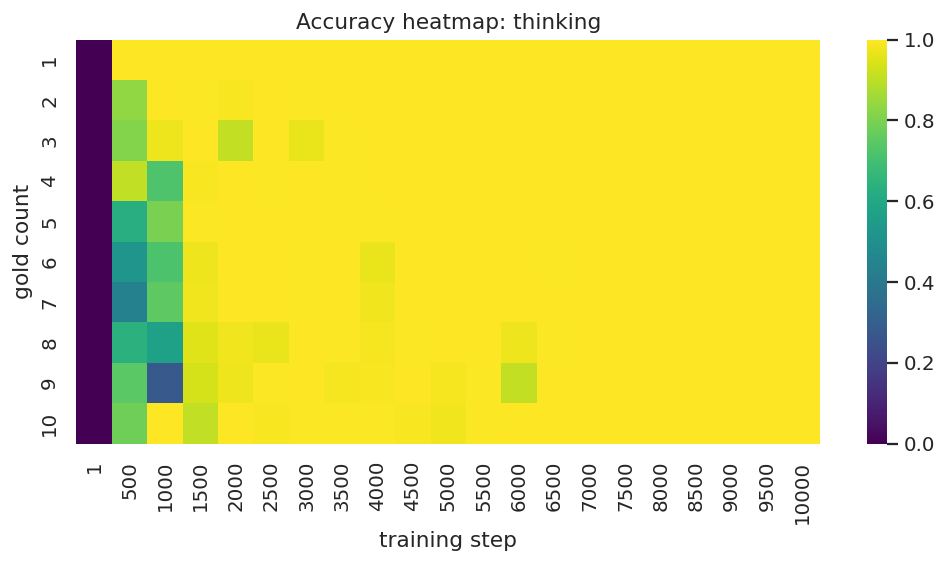

,count_bin,step,model_type,accuracy,n_examples,invalid_rate,eval_completion_loss,eval_final_answer_loss,mae,under_rate,over_rate,trace_exact_match_rate,trace_marker_precision,trace_marker_recall,trace_index_accuracy
114,high,9500,non_thinking,1.0,160000,0.0,2.980232e-09,0.000000e+00,0.0,0.0,0.0,NaN,NaN,NaN,NaN
115,low,9500,non_thinking,1.0,120000,0.0,4.271666e-09,0.000000e+00,0.0,0.0,0.0,NaN,NaN,NaN,NaN
116,mid,9500,non_thinking,1.0,120000,0.0,3.377596e-09,0.000000e+00,0.0,0.0,0.0,NaN,NaN,NaN,NaN
117,high,9500,thinking,1.0,160000,0.0,8.952395e-07,5.379319e-08,0.0,0.0,0.0,1.0,1.0,1.0,1.0
118,low,9500,thinking,1.0,120000,0.0,5.007183e-07,1.053015e-08,0.0,0.0,0.0,1.0,1.0,1.0,1.0
119,mid,9500,thinking,1.0,120000,0.0,7.331530e-07,1.132488e-08,0.0,0.0,0.0,1.0,1.0,1.0,1.0
120,high,10000,non_thinking,1.0,160000,0.0,2.905726e-09,0.000000e+00,0.0,0.0,0.0,NaN,NaN,NaN,NaN
121,low,10000,non_thinking,1.0,120000,0.0,4.271666e-09,0.000000e+00,0.0,0.0,0.0,NaN,NaN,NaN,NaN
122,mid,10000,non_thinking,1.0,120000,0.0,3.377596e-09,0.000000e+00,0.0,0.0,0.0,NaN,NaN,NaN,NaN
123,high,10000,thinking,1.0,160000,0.0,8.295671e-07,4.619360e-08,0.0,0.0,0.0,1.0,1.0,1.0,1.0


In [52]:
vocab = Vocab.build()
vocab.save(RUN_DIR / "vocab.json")

test_examples = balanced_examples(cfg["seq_len"], cfg["test_examples_per_count"], cfg["seed"] + 101)
val_examples = balanced_examples(cfg["seq_len"], cfg["val_examples_per_count"], cfg["seed"] + 202)

final_ckpt_ok = all((CHECKPOINT_DIR / "final" / model_type / "config.json").exists() for model_type in ["non_thinking", "thinking"])

if RUN_TRAINING and not (SKIP_TRAIN_IF_FINAL_CHECKPOINT_EXISTS and final_ckpt_ok):
    torch.manual_seed(cfg["seed"])
    random.seed(cfg["seed"])
    np.random.seed(cfg["seed"])
    models = {
        "non_thinking": build_model(vocab, cfg).to(cfg["device"]),
        "thinking": build_model(vocab, cfg).to(cfg["device"]),
    }
    optimizers = {
        name: AdamW(model.parameters(), lr=cfg["learning_rate"], betas=cfg["betas"], weight_decay=cfg["weight_decay"])
        for name, model in models.items()
    }
    rng = random.Random(cfg["seed"] + 303)
    train_rows = []
    eval_count_frames = []
    eval_bin_frames = []

    start_time = datetime.now()
    for step in tqdm(range(1, cfg["train_steps"] + 1), desc="v2 training"):
        base_batch = sample_batch(cfg["seq_len"], cfg["batch_size"], rng)
        lr = set_lr(optimizers["non_thinking"], step, cfg)
        set_lr(optimizers["thinking"], step, cfg)
        for model_type, model in models.items():
            model.train()
            rendered = [render_example(ex, model_type, vocab) for ex in base_batch]
            batch = collate_rendered(rendered, vocab, cfg["device"])
            optimizers[model_type].zero_grad(set_to_none=True)
            outputs = model(input_ids=batch["input_ids"], attention_mask=batch["attention_mask"], labels=batch["labels"])
            completion_loss = outputs.loss
            final_loss = final_answer_loss_from_logits(outputs.logits, batch, vocab)
            completion_loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), cfg["grad_clip_norm"])
            optimizers[model_type].step()
            if step == 1 or step % cfg["log_every"] == 0 or step == cfg["train_steps"]:
                train_rows.append(
                    {
                        "step": step,
                        "model_type": model_type,
                        "train_loss": float(completion_loss.detach().cpu()),
                        "train_completion_loss": float(completion_loss.detach().cpu()),
                        "train_final_answer_loss": float(final_loss.detach().cpu()),
                        "learning_rate": lr,
                    }
                )
        if step == 1 or step % cfg["eval_every"] == 0 or step == cfg["train_steps"]:
            by_count, by_bin = evaluate_all(step, models, val_examples, vocab, cfg)
            eval_count_frames.append(by_count)
            eval_bin_frames.append(by_bin)
            pd.concat(eval_count_frames, ignore_index=True).to_csv(RUN_DIR / "metrics_eval_by_count.csv", index=False)
            pd.concat(eval_bin_frames, ignore_index=True).to_csv(RUN_DIR / "metrics_eval_by_bin.csv", index=False)
            pd.DataFrame(train_rows).to_csv(RUN_DIR / "metrics_train.csv", index=False)
            if SAVE_CHECKPOINTS_AT_EVAL:
                save_checkpoint(models, vocab, f"step_{step:06d}")
            display(Markdown(f"step {step}: eval complete"))
    save_checkpoint(models, vocab, "final")
    pd.DataFrame(train_rows).to_csv(RUN_DIR / "metrics_train.csv", index=False)
else:
    display(Markdown("Loading existing final checkpoints."))
    models = load_final_models(vocab, cfg)

if not (RUN_DIR / "metrics_eval_by_count.csv").exists():
    by_count, by_bin = evaluate_all(cfg["train_steps"], models, val_examples, vocab, cfg)
    by_count.to_csv(RUN_DIR / "metrics_eval_by_count.csv", index=False)
    by_bin.to_csv(RUN_DIR / "metrics_eval_by_bin.csv", index=False)

plot_required(RUN_DIR)
display(pd.read_csv(RUN_DIR / "metrics_eval_by_bin.csv").tail(12))
        

## Hidden-State Probes

Probe features are collected under teacher forcing so token positions are known.

Important anti-leakage rule: prefix-count probes do not use the hidden state at numeric token `<k>` itself. The `pre_index_k` anchor uses the token immediately before `<k>`.
        

probe features non_thinking:   0%|          | 0/79 [00:00<?, ?it/s]

probe features non_thinking:   0%|          | 0/79 [00:00<?, ?it/s]

probe features thinking:   0%|          | 0/79 [00:00<?, ?it/s]

probe features thinking:   0%|          | 0/79 [00:00<?, ?it/s]

,model_type,layer,anchor_type,label_type,checkpoint_step,probe_accuracy,ridge_rounded_accuracy,probe_mae,probe_r2,n_train,n_test
2,non_thinking,layer_1,ans_token,final_count,10000,1.0,1.000000,0.000000,0.999893,5000,5000
6,non_thinking,layer_3,ans_token,final_count,10000,1.0,1.000000,0.000000,0.999947,5000,5000
4,non_thinking,layer_2,ans_token,final_count,10000,1.0,1.000000,0.000000,0.999920,5000,5000
33,thinking,layer_4,think_end,final_count,10000,1.0,1.000000,0.000000,0.999547,5000,5000
32,thinking,layer_4,pre_index_k,prefix_count,10000,1.0,0.999964,0.000036,0.999420,27500,27500
10,thinking,embeddings,ans_token,final_count,10000,1.0,1.000000,0.000000,1.000000,5000,5000
8,non_thinking,layer_4,ans_token,final_count,10000,1.0,1.000000,0.000000,0.999971,5000,5000
15,thinking,layer_1,ans_token,final_count,10000,1.0,1.000000,0.000000,0.999994,5000,5000
13,thinking,embeddings,think_end,final_count,10000,1.0,1.000000,0.000000,1.000000,5000,5000
12,thinking,embeddings,pre_index_k,prefix_count,10000,1.0,1.000000,0.000000,1.000000,27500,27500


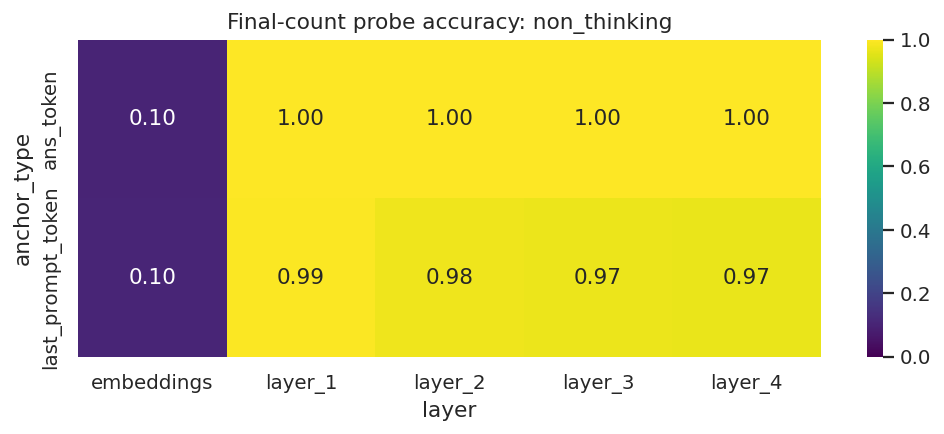

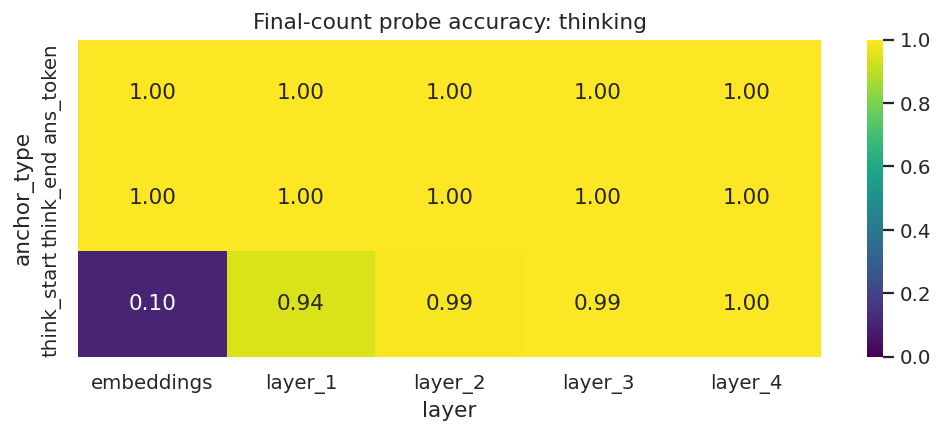

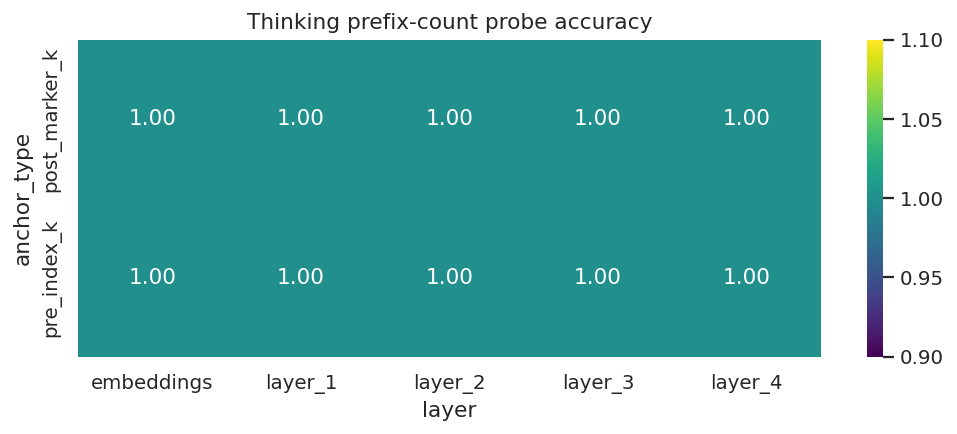

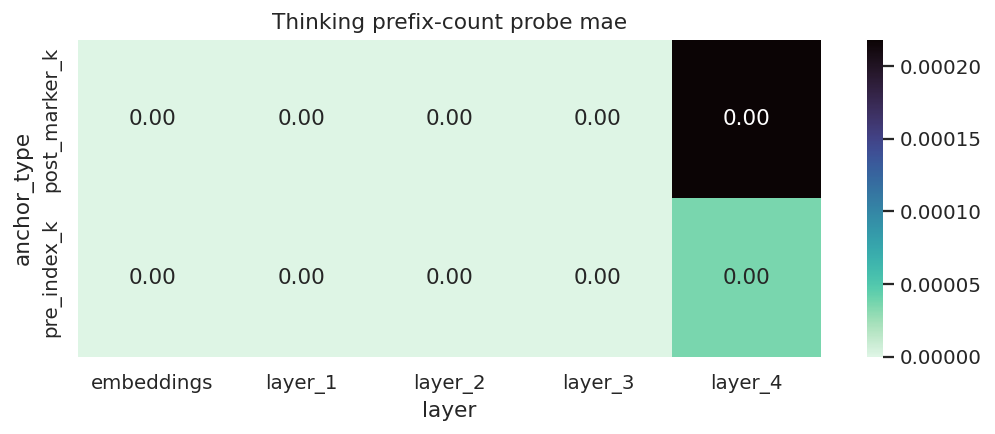

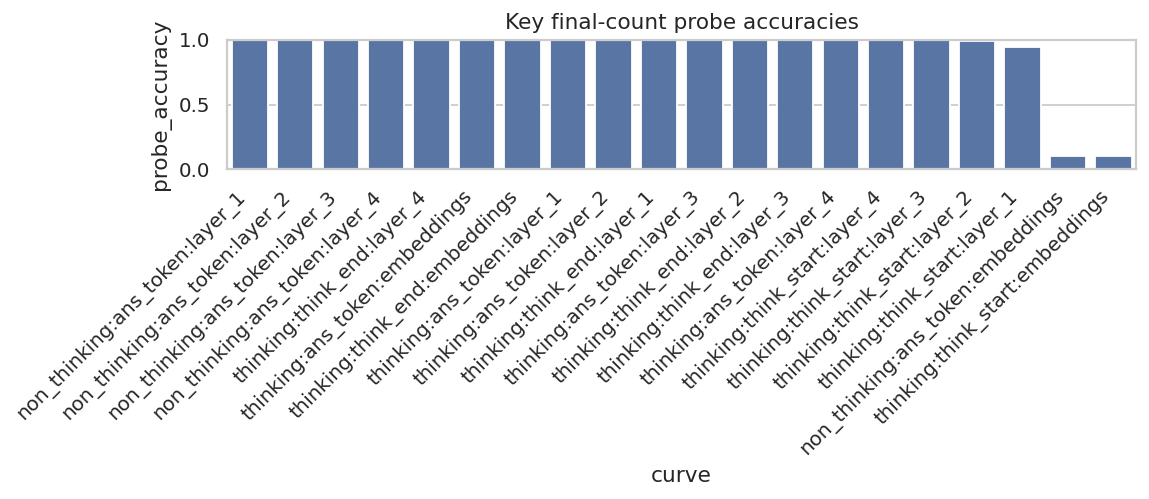

In [53]:
RIDGE_ALPHAS = np.logspace(-4, 4, 17)


def collect_probe_records(model: GPT2LMHeadModel, model_type: str, examples: list[BaseExample], vocab: Vocab, cfg: dict[str, Any], batch_size: int = 64) -> list[dict[str, Any]]:
    model.eval()
    rows = []
    with torch.no_grad():
        for start in tqdm(range(0, len(examples), batch_size), desc=f"probe features {model_type}", leave=False):
            batch_examples = examples[start : start + batch_size]
            rendered = [render_example(ex, model_type, vocab) for ex in batch_examples]
            batch = collate_rendered(rendered, vocab, cfg["device"])
            outputs = model(input_ids=batch["input_ids"], attention_mask=batch["attention_mask"], output_hidden_states=True)
            for layer_idx, hidden in enumerate(outputs.hidden_states):
                lname = "embeddings" if layer_idx == 0 else f"layer_{layer_idx}"
                hidden_np = hidden.detach().float().cpu().numpy()
                for i, (ex, r) in enumerate(zip(batch_examples, rendered)):
                    anchors = r["anchors"]
                    if model_type == "non_thinking":
                        for anchor in ["ans_token", "last_prompt_token"]:
                            rows.append(
                                {
                                    "model_type": model_type,
                                    "layer": lname,
                                    "anchor_type": anchor,
                                    "label_type": "final_count",
                                    "label": ex.count,
                                    "feature": hidden_np[i, anchors[anchor]].copy(),
                                }
                            )
                    else:
                        for anchor in ["think_start", "think_end", "ans_token"]:
                            rows.append(
                                {
                                    "model_type": model_type,
                                    "layer": lname,
                                    "anchor_type": anchor,
                                    "label_type": "final_count",
                                    "label": ex.count,
                                    "feature": hidden_np[i, anchors[anchor]].copy(),
                                }
                            )
                        for k, pos in enumerate(anchors["pre_index_positions"], start=1):
                            rows.append(
                                {
                                    "model_type": model_type,
                                    "layer": lname,
                                    "anchor_type": "pre_index_k",
                                    "label_type": "prefix_count",
                                    "label": k,
                                    "feature": hidden_np[i, pos].copy(),
                                }
                            )
                        for k, pos in enumerate(anchors["marker_positions"], start=1):
                            rows.append(
                                {
                                    "model_type": model_type,
                                    "layer": lname,
                                    "anchor_type": "post_marker_k",
                                    "label_type": "prefix_count",
                                    "label": k,
                                    "feature": hidden_np[i, pos].copy(),
                                }
                            )
    return rows


def fit_probe_group(train_rows: list[dict[str, Any]], test_rows: list[dict[str, Any]]) -> dict[str, float]:
    X_train = np.stack([r["feature"] for r in train_rows])
    y_train = np.array([r["label"] for r in train_rows])
    X_test = np.stack([r["feature"] for r in test_rows])
    y_test = np.array([r["label"] for r in test_rows])
    cls = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, n_jobs=-1))
    cls.fit(X_train, y_train)
    cls_pred = cls.predict(X_test)
    ridge = make_pipeline(StandardScaler(), RidgeCV(alphas=RIDGE_ALPHAS))
    ridge.fit(X_train, y_train.astype(float))
    ridge_pred = ridge.predict(X_test)
    rounded = np.clip(np.rint(ridge_pred), 1, 10).astype(int)
    return {
        "probe_accuracy": float(accuracy_score(y_test, cls_pred)),
        "ridge_rounded_accuracy": float(accuracy_score(y_test, rounded)),
        "probe_mae": float(mean_absolute_error(y_test, rounded)),
        "probe_r2": float(r2_score(y_test.astype(float), ridge_pred)),
        "n_train": int(len(train_rows)),
        "n_test": int(len(test_rows)),
    }


def run_probes(models: dict[str, GPT2LMHeadModel], vocab: Vocab, cfg: dict[str, Any]) -> pd.DataFrame:
    train_examples = balanced_examples(cfg["seq_len"], cfg["probe_train_examples_per_count"], cfg["seed"] + 404)
    test_examples = balanced_examples(cfg["seq_len"], cfg["probe_test_examples_per_count"], cfg["seed"] + 505)
    train_records, test_records = [], []
    for model_type, model in models.items():
        train_records.extend(collect_probe_records(model, model_type, train_examples, vocab, cfg))
        test_records.extend(collect_probe_records(model, model_type, test_examples, vocab, cfg))
    train_df = pd.DataFrame([{k: v for k, v in r.items() if k != "feature"} for r in train_records])
    test_df = pd.DataFrame([{k: v for k, v in r.items() if k != "feature"} for r in test_records])
    rows = []
    keys = ["model_type", "layer", "anchor_type", "label_type"]
    for key_values, idxs in train_df.groupby(keys).groups.items():
        mask_test = np.ones(len(test_df), dtype=bool)
        for col, val in zip(keys, key_values):
            mask_test &= test_df[col].to_numpy() == val
        test_idxs = np.where(mask_test)[0]
        if len(test_idxs) < 10:
            continue
        result = fit_probe_group([train_records[i] for i in idxs], [test_records[i] for i in test_idxs])
        rows.append(dict(zip(keys, key_values)) | {"checkpoint_step": cfg["train_steps"], **result})
    metrics = pd.DataFrame(rows)
    metrics.to_csv(PROBES_DIR / "probe_metrics.csv", index=False)
    return metrics


def plot_probe_results(metrics: pd.DataFrame) -> None:
    if metrics.empty:
        return
    for model_type in ["non_thinking", "thinking"]:
        final = metrics[(metrics["model_type"] == model_type) & (metrics["label_type"] == "final_count")]
        if not final.empty:
            mat = final.pivot_table(index="anchor_type", columns="layer", values="probe_accuracy", aggfunc="max")
            plt.figure(figsize=(8, 3.5))
            sns.heatmap(mat, vmin=0, vmax=1, cmap="viridis", annot=True, fmt=".2f")
            plt.title(f"Final-count probe accuracy: {model_type}")
            plt.tight_layout()
            plt.savefig(PROBES_DIR / f"probe_final_count_accuracy_heatmap_{model_type}.png", bbox_inches="tight")
            plt.show()
    prefix = metrics[(metrics["model_type"] == "thinking") & (metrics["label_type"] == "prefix_count")]
    if not prefix.empty:
        for metric, name in [("probe_accuracy", "accuracy"), ("probe_mae", "mae")]:
            mat = prefix.pivot_table(index="anchor_type", columns="layer", values=metric, aggfunc="max" if metric == "probe_accuracy" else "min")
            plt.figure(figsize=(8, 3.5))
            sns.heatmap(mat, cmap="viridis" if metric == "probe_accuracy" else "mako_r", annot=True, fmt=".2f")
            plt.title(f"Thinking prefix-count probe {name}")
            plt.tight_layout()
            plt.savefig(PROBES_DIR / f"probe_prefix_count_{name}_heatmap_thinking.png", bbox_inches="tight")
            plt.show()
    key = metrics[
        ((metrics["model_type"] == "non_thinking") & (metrics["anchor_type"] == "ans_token") & (metrics["label_type"] == "final_count"))
        | ((metrics["model_type"] == "thinking") & (metrics["anchor_type"].isin(["think_start", "think_end", "ans_token"])) & (metrics["label_type"] == "final_count"))
    ].copy()
    if not key.empty:
        key["curve"] = key["model_type"] + ":" + key["anchor_type"] + ":" + key["layer"]
        plt.figure(figsize=(9, 4))
        sns.barplot(data=key.sort_values("probe_accuracy", ascending=False).head(20), x="curve", y="probe_accuracy")
        plt.xticks(rotation=45, ha="right")
        plt.ylim(0, 1)
        plt.title("Key final-count probe accuracies")
        plt.tight_layout()
        plt.savefig(PROBES_DIR / "probe_accuracy_vs_training_step_ans_token.png", bbox_inches="tight")
        plt.show()


if RUN_PROBES:
    probe_metrics = run_probes(models, vocab, cfg)
    display(probe_metrics.sort_values("probe_accuracy", ascending=False).head(20))
    plot_probe_results(probe_metrics)
        

## Attention and Retrieval Analysis

Attention is diagnostic rather than causal. The thinking analysis measures whether trace item `k` attends to prompt needle `j`, especially along the diagonal `k=j`.
        

Loading weights:   0%|          | 0/52 [00:00<?, ?it/s]

attention non_thinking:   0%|          | 0/1000 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/52 [00:00<?, ?it/s]

attention thinking:   0%|          | 0/1000 [00:00<?, ?it/s]

**Non-thinking attention summary**

,layer,head,ans_to_all_needles_mass,top_n_retrieval_recall
0,1,0,0.090282,1.000000
1,1,1,0.105009,1.000000
2,1,2,0.110506,1.000000
3,1,3,0.104464,1.000000
4,2,0,0.021252,0.034294


**Thinking attention summary**

,query_anchor,layer,head,diagonal_dominance,correct_top1_rate
0,index_token_k,1,0,0.552526,0.336862
1,index_token_k,1,1,0.548408,0.298923
2,index_token_k,1,2,0.551618,0.298992
3,index_token_k,1,3,0.547049,0.292230
4,index_token_k,2,0,0.635882,0.405865


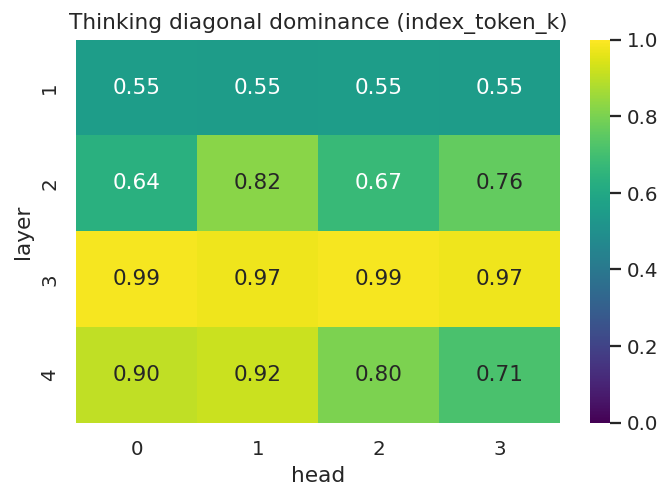

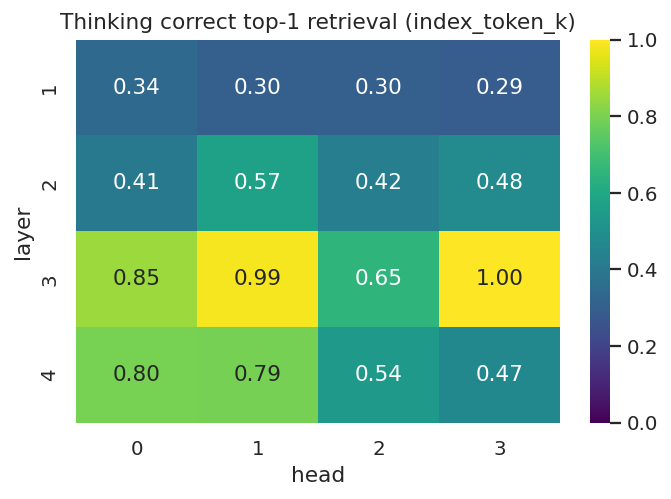

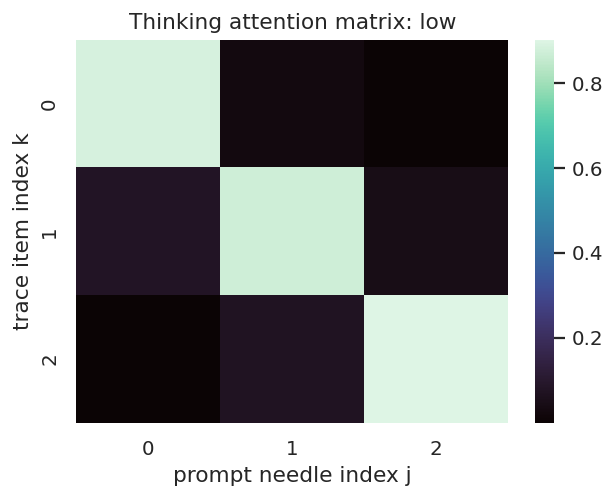

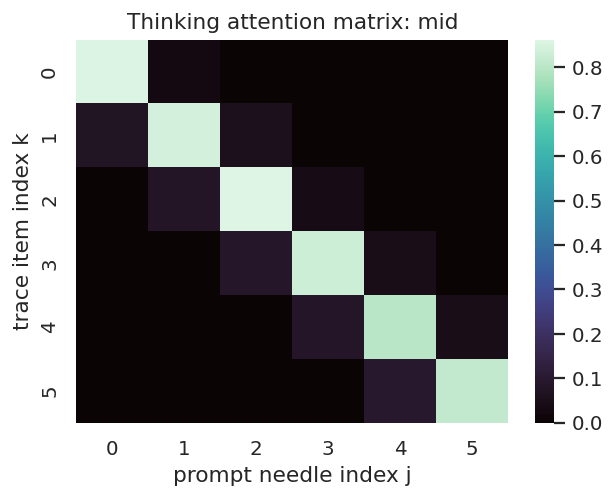

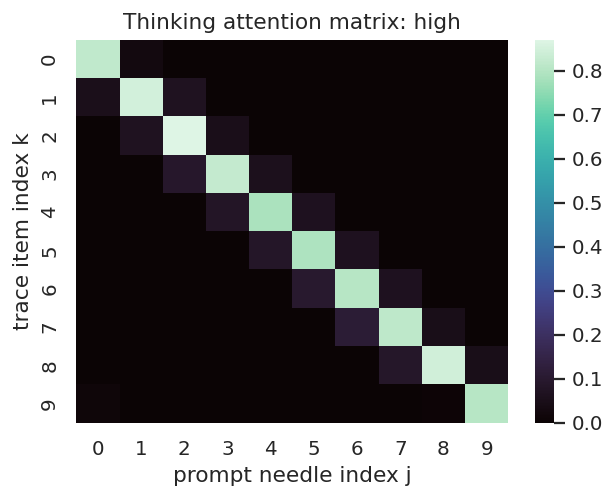

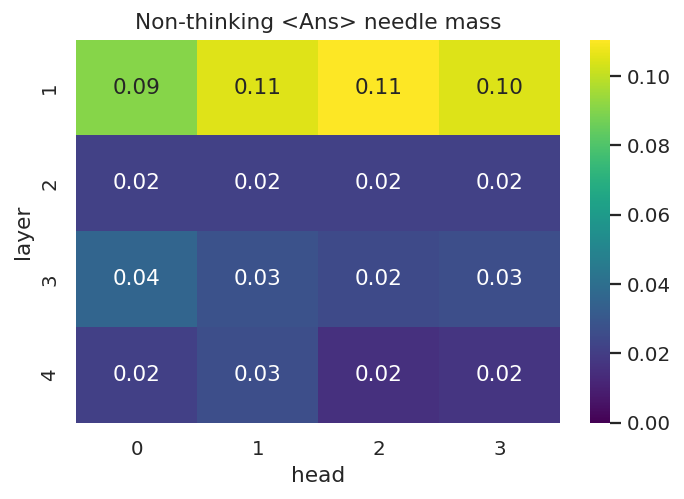

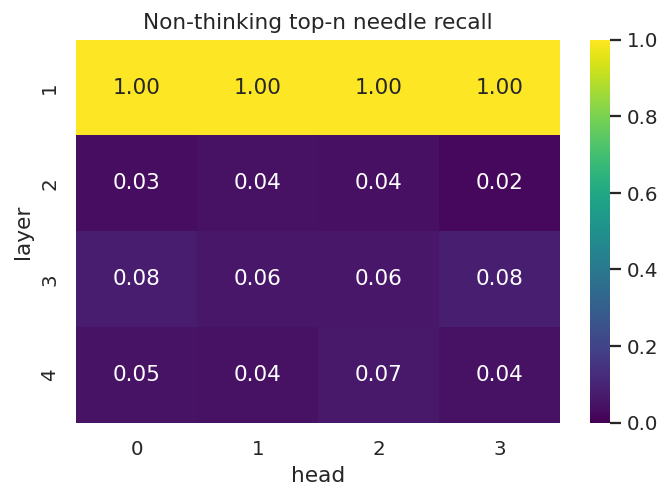

In [54]:
def attention_entropy(weights: np.ndarray) -> float:
    p = weights / max(float(weights.sum()), 1e-12)
    p = p[p > 0]
    return float(-(p * np.log(p)).sum())


@torch.no_grad()
def run_attention(models: dict[str, GPT2LMHeadModel], vocab: Vocab, cfg: dict[str, Any]) -> tuple[pd.DataFrame, pd.DataFrame]:
    examples = balanced_examples(cfg["seq_len"], cfg["attention_examples_per_count"], cfg["seed"] + 606)
    non_rows = []
    think_rows = []
    for model_type, source_model in models.items():
        # Hugging Face defaults to SDPA attention on recent torch/transformers builds.
        # SDPA is faster but does not materialize attention matrices. Reload only the
        # attention-analysis copy with eager attention, leaving training/eval untouched.
        eager_path = CHECKPOINT_DIR / "final" / model_type
        if eager_path.exists():
            model = GPT2LMHeadModel.from_pretrained(eager_path, attn_implementation="eager").to(cfg["device"])
        else:
            model = source_model
            model.config._attn_implementation = "eager"
        model.eval()
        for ex in tqdm(examples, desc=f"attention {model_type}", leave=False):
            r = render_example(ex, model_type, vocab)
            input_ids = torch.tensor([r["input_ids"]], dtype=torch.long, device=cfg["device"])
            attention_mask = torch.ones_like(input_ids)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, output_attentions=True)
            attentions = outputs.attentions
            prompt_indices = list(range(r["anchors"]["prompt_start"], r["anchors"]["prompt_end_exclusive"]))
            needle_indices = [1 + pos for pos in ex.needle_positions]
            noise_indices = [idx for idx in prompt_indices if idx not in set(needle_indices)]
            if model_type == "non_thinking":
                q = r["anchors"]["ans_token"]
                n = ex.count
                for layer_idx, layer_attn in enumerate(attentions, start=1):
                    arr = layer_attn[0, :, q, :].detach().float().cpu().numpy()
                    for head, weights in enumerate(arr):
                        needle_mass = float(weights[needle_indices].sum())
                        noise_mass = float(weights[noise_indices].sum())
                        top_prompt = np.array(prompt_indices)[np.argsort(weights[prompt_indices])[-n:]]
                        recall = len(set(top_prompt.tolist()) & set(needle_indices)) / n
                        non_rows.append(
                            {
                                "model_type": model_type,
                                "count": ex.count,
                                "count_bin": count_bin(ex.count),
                                "layer": layer_idx,
                                "head": head,
                                "ans_to_all_needles_mass": needle_mass,
                                "ans_to_noise_mass": noise_mass,
                                "needle_vs_noise_ratio": needle_mass / (noise_mass + 1e-12),
                                "attention_entropy_over_prompt_body": attention_entropy(weights[prompt_indices]),
                                "top_n_retrieval_recall": recall,
                            }
                        )
            else:
                anchors = r["anchors"]
                query_sets = {
                    "index_token_k": anchors["index_positions"],
                    "marker_token_k": anchors["marker_positions"],
                    "pre_index_k": anchors["pre_index_positions"],
                }
                for query_anchor, query_positions in query_sets.items():
                    for layer_idx, layer_attn in enumerate(attentions, start=1):
                        arr = layer_attn[0, :, :, :].detach().float().cpu().numpy()
                        for head in range(arr.shape[0]):
                            A = np.zeros((ex.count, ex.count), dtype=np.float32)
                            needle_mass_total = 0.0
                            noise_mass_total = 0.0
                            top1 = []
                            for k_idx, q in enumerate(query_positions):
                                weights = arr[head, q, :]
                                A[k_idx] = weights[needle_indices]
                                needle_mass_total += float(weights[needle_indices].sum())
                                noise_mass_total += float(weights[noise_indices].sum())
                                top1.append(int(np.argmax(weights[needle_indices]) == k_idx))
                            diag = float(np.diag(A).mean())
                            off = float((A.sum() - np.diag(A).sum()) / max(ex.count * (ex.count - 1), 1))
                            think_rows.append(
                                {
                                    "model_type": model_type,
                                    "count": ex.count,
                                    "count_bin": count_bin(ex.count),
                                    "layer": layer_idx,
                                    "head": head,
                                    "query_anchor": query_anchor,
                                    "diagonal_mass": diag,
                                    "off_diagonal_mass": off,
                                    "diagonal_dominance": diag / (diag + off + 1e-12),
                                    "correct_top1_rate": float(np.mean(top1)),
                                    "needle_attention_mass": needle_mass_total / ex.count,
                                    "noise_attention_mass": noise_mass_total / ex.count,
                                    "needle_vs_noise_ratio": needle_mass_total / (noise_mass_total + 1e-12),
                                    "matrix_json": json.dumps(A.tolist()),
                                }
                            )
    non = pd.DataFrame(non_rows)
    think = pd.DataFrame(think_rows)
    non.to_csv(ATTENTION_DIR / "attention_nonthinking_metrics.csv", index=False)
    think.to_csv(ATTENTION_DIR / "attention_thinking_metrics.csv", index=False)
    return non, think


def plot_attention(non: pd.DataFrame, think: pd.DataFrame) -> None:
    if not think.empty:
        for metric, filename, title in [
            ("diagonal_dominance", "attention_thinking_diagonal_dominance_by_layer_head.png", "Thinking diagonal dominance"),
            ("correct_top1_rate", "attention_thinking_correct_top1_by_layer_head.png", "Thinking correct top-1 retrieval"),
        ]:
            best_anchor = think.groupby("query_anchor")[metric].mean().sort_values(ascending=False).index[0]
            agg = think[think["query_anchor"] == best_anchor].groupby(["layer", "head"], as_index=False)[metric].mean()
            mat = agg.pivot(index="layer", columns="head", values=metric)
            plt.figure(figsize=(5.5, 4))
            sns.heatmap(mat, vmin=0, vmax=1, cmap="viridis", annot=True, fmt=".2f")
            plt.title(f"{title} ({best_anchor})")
            plt.tight_layout()
            plt.savefig(ATTENTION_DIR / filename, bbox_inches="tight")
            plt.show()
        best = think.sort_values("diagonal_dominance", ascending=False).iloc[0]
        for bin_name in ["low", "mid", "high"]:
            rows = think[
                (think["query_anchor"] == best["query_anchor"])
                & (think["layer"] == best["layer"])
                & (think["head"] == best["head"])
                & (think["count_bin"] == bin_name)
            ]
            if rows.empty:
                continue
            matrices = [np.array(json.loads(x), dtype=float) for x in rows["matrix_json"]]
            max_n = max(m.shape[0] for m in matrices)
            padded = []
            for m in matrices:
                p = np.full((max_n, max_n), np.nan)
                p[: m.shape[0], : m.shape[1]] = m
                padded.append(p)
            avg = np.nanmean(np.stack(padded), axis=0)
            plt.figure(figsize=(5, 4))
            sns.heatmap(avg, cmap="mako", annot=PRESET == "debug", fmt=".3f")
            plt.xlabel("prompt needle index j")
            plt.ylabel("trace item index k")
            plt.title(f"Thinking attention matrix: {bin_name}")
            plt.tight_layout()
            plt.savefig(ATTENTION_DIR / f"attention_matrix_thinking_best_head_{bin_name}.png", bbox_inches="tight")
            plt.show()
    if not non.empty:
        for metric, filename, title in [
            ("ans_to_all_needles_mass", "attention_nonthinking_ans_needle_mass_by_layer_head.png", "Non-thinking <Ans> needle mass"),
            ("top_n_retrieval_recall", "attention_nonthinking_topn_recall_by_layer_head.png", "Non-thinking top-n needle recall"),
        ]:
            agg = non.groupby(["layer", "head"], as_index=False)[metric].mean()
            mat = agg.pivot(index="layer", columns="head", values=metric)
            plt.figure(figsize=(5.5, 4))
            sns.heatmap(mat, vmin=0, vmax=1 if metric == "top_n_retrieval_recall" else None, cmap="viridis", annot=True, fmt=".2f")
            plt.title(title)
            plt.tight_layout()
            plt.savefig(ATTENTION_DIR / filename, bbox_inches="tight")
            plt.show()


if RUN_ATTENTION:
    non_attn, think_attn = run_attention(models, vocab, cfg)
    display(Markdown("**Non-thinking attention summary**"))
    display(non_attn.groupby(["layer", "head"], as_index=False)[["ans_to_all_needles_mass", "top_n_retrieval_recall"]].mean().head())
    display(Markdown("**Thinking attention summary**"))
    display(think_attn.groupby(["query_anchor", "layer", "head"], as_index=False)[["diagonal_dominance", "correct_top1_rate"]].mean().head())
    plot_attention(non_attn, think_attn)
        

## Result Summary

This cell reads the saved CSV files and prints a compact interpretation.
        

In [55]:
train_df = pd.read_csv(RUN_DIR / "metrics_train.csv") if (RUN_DIR / "metrics_train.csv").exists() else pd.DataFrame()
count_df = pd.read_csv(RUN_DIR / "metrics_eval_by_count.csv")
bin_df = pd.read_csv(RUN_DIR / "metrics_eval_by_bin.csv")
final_step = int(count_df["step"].max())
final_count = count_df[count_df["step"] == final_step]
final_bin = bin_df[bin_df["step"] == final_step]

display(Markdown(f"### Final step: {final_step}"))
display(final_bin[["model_type", "count_bin", "accuracy", "eval_final_answer_loss", "invalid_rate", "mae"]])
display(final_count[["model_type", "count", "accuracy", "eval_final_answer_loss", "invalid_rate", "mae"]])

lines = []
for model_type in ["non_thinking", "thinking"]:
    sub = final_bin[final_bin["model_type"] == model_type]
    if sub.empty:
        continue
    low = sub[sub["count_bin"] == "low"]["accuracy"].mean()
    mid = sub[sub["count_bin"] == "mid"]["accuracy"].mean()
    high = sub[sub["count_bin"] == "high"]["accuracy"].mean()
    lines.append(f"- `{model_type}` final accuracy by bin: low={low:.3f}, mid={mid:.3f}, high={high:.3f}.")
if not final_bin.empty:
    winner = final_bin.groupby("model_type")["accuracy"].mean().sort_values(ascending=False)
    lines.append(f"- Overall final-bin average winner: `{winner.index[0]}` ({winner.iloc[0]:.3f}).")
if RUN_PROBES and (PROBES_DIR / "probe_metrics.csv").exists():
    probes = pd.read_csv(PROBES_DIR / "probe_metrics.csv")
    best = probes.sort_values("probe_accuracy", ascending=False).head(5)
    lines.append("- Best probe rows:")
    for _, row in best.iterrows():
        lines.append(f"  - {row['model_type']} {row['layer']} {row['anchor_type']} {row['label_type']}: acc={row['probe_accuracy']:.3f}, mae={row['probe_mae']:.3f}, r2={row['probe_r2']:.3f}.")
if RUN_ATTENTION and (ATTENTION_DIR / "attention_thinking_metrics.csv").exists():
    think = pd.read_csv(ATTENTION_DIR / "attention_thinking_metrics.csv")
    if not think.empty:
        best = think.groupby(["query_anchor", "layer", "head"], as_index=False)["diagonal_dominance"].mean().sort_values("diagonal_dominance", ascending=False).head(3)
        lines.append("- Best thinking retrieval-like attention heads by diagonal dominance:")
        for _, row in best.iterrows():
            lines.append(f"  - {row['query_anchor']} layer={int(row['layer'])} head={int(row['head'])}: diagonal_dominance={row['diagonal_dominance']:.3f}.")

display(Markdown("\n".join(lines)))
        

### Final step: 10000

,model_type,count_bin,accuracy,eval_final_answer_loss,invalid_rate,mae
120,non_thinking,high,1.0,0.000000e+00,0.0,0.0
121,non_thinking,low,1.0,0.000000e+00,0.0,0.0
122,non_thinking,mid,1.0,0.000000e+00,0.0,0.0
123,thinking,high,1.0,4.619360e-08,0.0,0.0
124,thinking,low,1.0,1.152356e-08,0.0,0.0
125,thinking,mid,1.0,1.231829e-08,0.0,0.0


,model_type,count,accuracy,eval_final_answer_loss,invalid_rate,mae
400,non_thinking,1,1.0,0.000000e+00,0.0,0.0
401,non_thinking,2,1.0,0.000000e+00,0.0,0.0
402,non_thinking,3,1.0,0.000000e+00,0.0,0.0
403,non_thinking,4,1.0,0.000000e+00,0.0,0.0
404,non_thinking,5,1.0,0.000000e+00,0.0,0.0
405,non_thinking,6,1.0,0.000000e+00,0.0,0.0
406,non_thinking,7,1.0,0.000000e+00,0.0,0.0
407,non_thinking,8,1.0,0.000000e+00,0.0,0.0
408,non_thinking,9,1.0,0.000000e+00,0.0,0.0
409,non_thinking,10,1.0,0.000000e+00,0.0,0.0


- `non_thinking` final accuracy by bin: low=1.000, mid=1.000, high=1.000.
- `thinking` final accuracy by bin: low=1.000, mid=1.000, high=1.000.
- Overall final-bin average winner: `non_thinking` (1.000).
- Best probe rows:
  - non_thinking layer_1 ans_token final_count: acc=1.000, mae=0.000, r2=1.000.
  - non_thinking layer_3 ans_token final_count: acc=1.000, mae=0.000, r2=1.000.
  - non_thinking layer_2 ans_token final_count: acc=1.000, mae=0.000, r2=1.000.
  - thinking layer_4 think_end final_count: acc=1.000, mae=0.000, r2=1.000.
  - thinking layer_4 pre_index_k prefix_count: acc=1.000, mae=0.000, r2=0.999.
- Best thinking retrieval-like attention heads by diagonal dominance:
  - index_token_k layer=3 head=0: diagonal_dominance=0.988.
  - index_token_k layer=3 head=2: diagonal_dominance=0.985.
  - index_token_k layer=3 head=3: diagonal_dominance=0.974.

## Targeted Retrieval Deep Dive

This section tests the three most interesting mechanistic hypotheses from the v2 result:

1. **Targeted retrieval head.** The thinking model may contain a trace-time head that maps trace item `k` to prompt needle `k`.
2. **Broad aggregation in non-thinking.** The non-thinking model may solve the final answer through a less sequential, more global aggregation path.
3. **Mechanistic importance.** If the targeted head is meaningful, it should appear during training and/or affect behavior when ablated.

The cells below are post-hoc analyses. They read existing metrics/checkpoints from `RUN_DIR` and do not retrain the models.
        

In [56]:
DEEP_DIVE_ATTENTION_EXAMPLES_PER_COUNT = 20
RUN_DEEP_DIVE_DYNAMICS = True
RUN_DEEP_DIVE_HEAD_ABLATION = True
DEEP_DIVE_ABLATION_EXAMPLES_PER_COUNT = 50


def latest_saved_v2_run() -> Path | None:
    candidates = sorted(Path("colab_results").glob("v2_marker_trace_*_seed*/run"), key=lambda p: p.stat().st_mtime, reverse=True)
    return candidates[0] if candidates else None


def resolve_analysis_run_dir() -> Path:
    if (RUN_DIR / "metrics_eval_by_count.csv").exists():
        return RUN_DIR
    saved = latest_saved_v2_run()
    if saved is not None:
        return saved
    raise FileNotFoundError("Could not find v2 run metrics. Run training/attention first or copy a saved bundle into colab_results/.")


ANALYSIS_RUN_DIR = resolve_analysis_run_dir()
ANALYSIS_CHECKPOINT_DIR = ANALYSIS_RUN_DIR / "checkpoints"
ANALYSIS_ATTENTION_DIR = ANALYSIS_RUN_DIR / "attention"
ANALYSIS_DEEP_DIVE_DIR = ANALYSIS_RUN_DIR / "targeted_retrieval_deep_dive"
ANALYSIS_DEEP_DIVE_DIR.mkdir(parents=True, exist_ok=True)
ANALYSIS_CFG = dict(cfg)
analysis_config_path = ANALYSIS_RUN_DIR / "config.json"
if analysis_config_path.exists():
    with analysis_config_path.open("r", encoding="utf-8") as f:
        ANALYSIS_CFG.update(json.load(f))
ANALYSIS_CFG["device"] = cfg["device"]

display(Markdown(f"**Deep-dive source run:** `{ANALYSIS_RUN_DIR}`"))

count_eval_dd = pd.read_csv(ANALYSIS_RUN_DIR / "metrics_eval_by_count.csv")
bin_eval_dd = pd.read_csv(ANALYSIS_RUN_DIR / "metrics_eval_by_bin.csv")
non_attn_dd = pd.read_csv(ANALYSIS_ATTENTION_DIR / "attention_nonthinking_metrics.csv")
think_attn_dd = pd.read_csv(ANALYSIS_ATTENTION_DIR / "attention_thinking_metrics.csv")

display(Markdown(
    "**Metric definitions.** "
    "`correct_top1_rate` = for trace step k, whether the highest-attended prompt needle is needle k. "
    "`diagonal_dominance` = diagonal attention mass divided by diagonal plus off-diagonal needle mass. "
    "`top_n_retrieval_recall` = for non-thinking <Ans>, among the top n prompt positions, what fraction are true needles. "
    "`needle_attention_mass` and `ans_to_all_needles_mass` are raw attention mass to true needle positions."
))
        

**Deep-dive source run:** `runs/v2_marker_trace_seed1234_main`

**Metric definitions.** `correct_top1_rate` = for trace step k, whether the highest-attended prompt needle is needle k. `diagonal_dominance` = diagonal attention mass divided by diagonal plus off-diagonal needle mass. `top_n_retrieval_recall` = for non-thinking <Ans>, among the top n prompt positions, what fraction are true needles. `needle_attention_mass` and `ans_to_all_needles_mass` are raw attention mass to true needle positions.

### Hypothesis 1: thinking has a targeted retrieval head

The table ranks thinking-model heads by whether trace item `k` attends to prompt needle `k`.  
Rows are grouped by `query_anchor`, `layer`, and `head`:

- `index_token_k`: the generated count index token `<k>` in the trace;
- `marker_token_k`: the generated marker token after `<k>`;
- `pre_index_k`: the token immediately before index `<k>`.
        

,query_anchor,layer,head,diagonal_dominance,correct_top1_rate,needle_attention_mass,noise_attention_mass,needle_vs_noise_ratio
11,index_token_k,3,3,0.973741,0.999800,0.936602,0.059920,20.966442
9,index_token_k,3,1,0.973048,0.985954,0.777481,0.216169,5.725534
8,index_token_k,3,0,0.988241,0.850336,0.051550,0.943838,0.058689
12,index_token_k,4,0,0.903464,0.796816,0.010678,0.988542,0.011488
13,index_token_k,4,1,0.920372,0.791226,0.056741,0.939756,0.067182
10,index_token_k,3,2,0.985240,0.651334,0.106906,0.891800,0.129454
5,index_token_k,2,1,0.824129,0.566505,0.002287,0.934484,0.002454
14,index_token_k,4,2,0.802881,0.538936,0.009332,0.737022,0.013667
7,index_token_k,2,3,0.761111,0.475621,0.204277,0.646849,0.411806
15,index_token_k,4,3,0.712723,0.465523,0.014505,0.741980,0.020186


**Best targeted-retrieval candidate:** `index_token_k`, layer `3`, head `3`; correct_top1=1.000, diagonal_dominance=0.974, needle_mass=0.937.

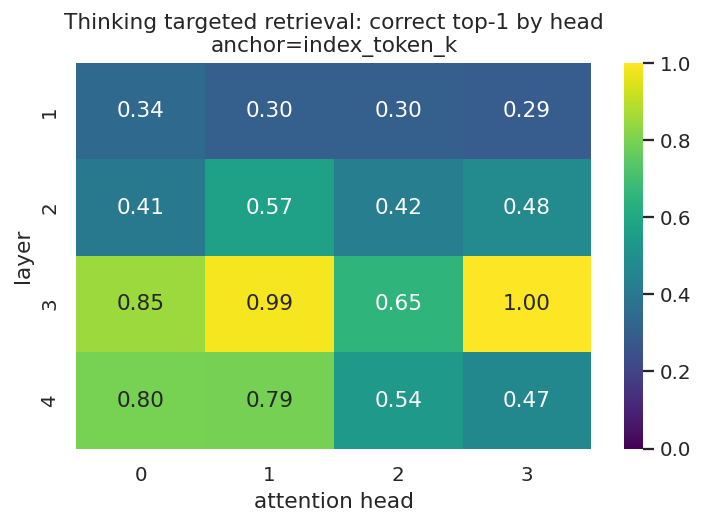

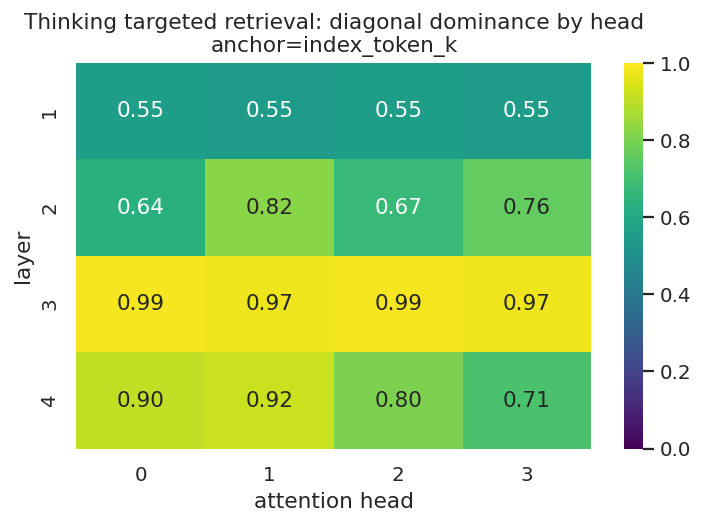

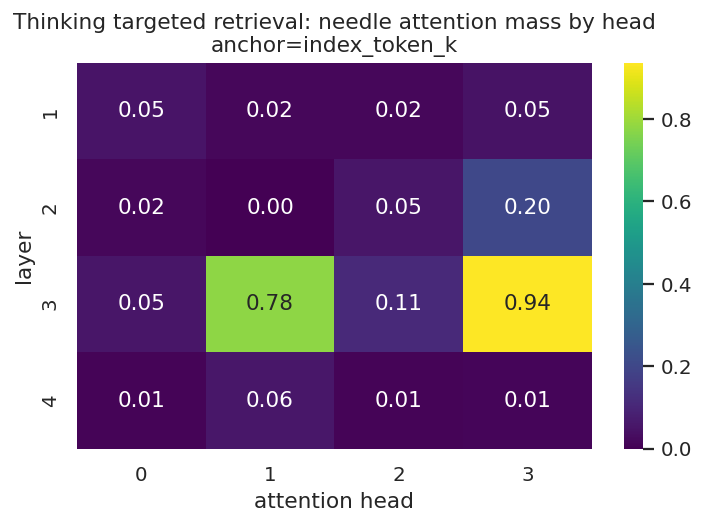

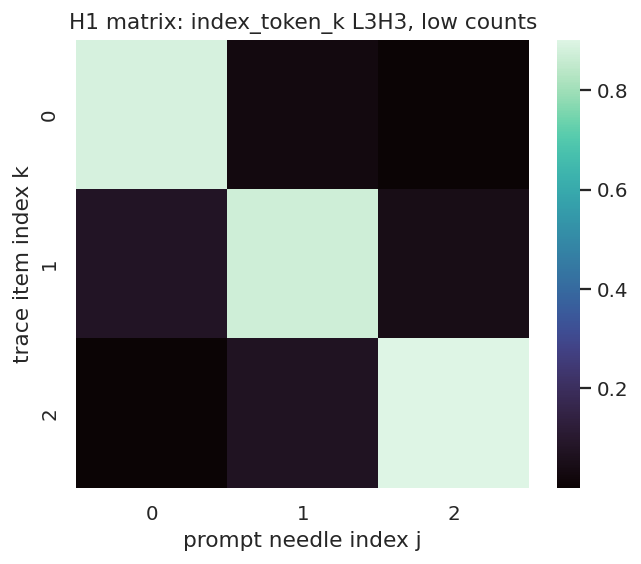

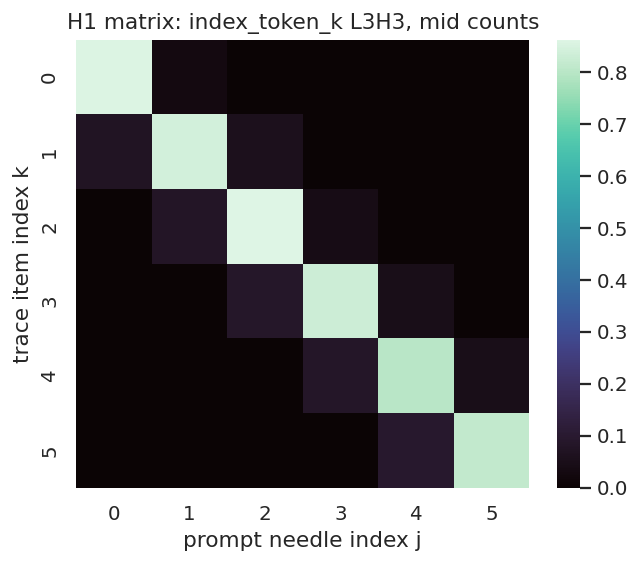

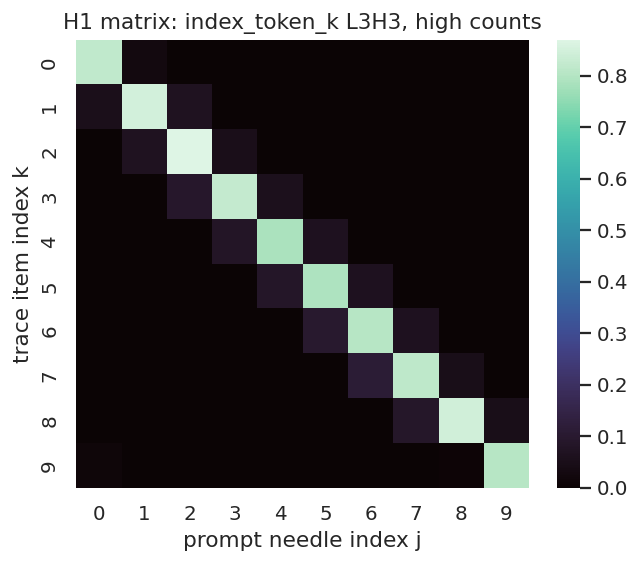

In [57]:
thinking_head_rank = (
    think_attn_dd
    .groupby(["query_anchor", "layer", "head"], as_index=False)
    .agg(
        diagonal_dominance=("diagonal_dominance", "mean"),
        correct_top1_rate=("correct_top1_rate", "mean"),
        needle_attention_mass=("needle_attention_mass", "mean"),
        noise_attention_mass=("noise_attention_mass", "mean"),
        needle_vs_noise_ratio=("needle_vs_noise_ratio", "mean"),
    )
    .sort_values(["correct_top1_rate", "diagonal_dominance", "needle_attention_mass"], ascending=False)
)

display(thinking_head_rank.head(12))

best_thinking_head = thinking_head_rank.iloc[0].to_dict()
BEST_QUERY_ANCHOR = str(best_thinking_head["query_anchor"])
BEST_LAYER = int(best_thinking_head["layer"])
BEST_HEAD = int(best_thinking_head["head"])

display(Markdown(
    f"**Best targeted-retrieval candidate:** `{BEST_QUERY_ANCHOR}`, layer `{BEST_LAYER}`, head `{BEST_HEAD}`; "
    f"correct_top1={best_thinking_head['correct_top1_rate']:.3f}, "
    f"diagonal_dominance={best_thinking_head['diagonal_dominance']:.3f}, "
    f"needle_mass={best_thinking_head['needle_attention_mass']:.3f}."
))

for metric, title, filename in [
    ("correct_top1_rate", "Thinking targeted retrieval: correct top-1 by head", "h1_thinking_correct_top1_by_head.png"),
    ("diagonal_dominance", "Thinking targeted retrieval: diagonal dominance by head", "h1_thinking_diagonal_dominance_by_head.png"),
    ("needle_attention_mass", "Thinking targeted retrieval: needle attention mass by head", "h1_thinking_needle_mass_by_head.png"),
]:
    agg = thinking_head_rank[thinking_head_rank["query_anchor"] == BEST_QUERY_ANCHOR]
    mat = agg.pivot(index="layer", columns="head", values=metric)
    plt.figure(figsize=(5.8, 4.2))
    sns.heatmap(mat, vmin=0, vmax=1 if metric != "needle_attention_mass" else None, cmap="viridis", annot=True, fmt=".2f")
    plt.title(f"{title}\nanchor={BEST_QUERY_ANCHOR}")
    plt.xlabel("attention head")
    plt.ylabel("layer")
    plt.tight_layout()
    plt.savefig(ANALYSIS_DEEP_DIVE_DIR / filename, bbox_inches="tight")
    plt.show()

rows = think_attn_dd[
    (think_attn_dd["query_anchor"] == BEST_QUERY_ANCHOR)
    & (think_attn_dd["layer"] == BEST_LAYER)
    & (think_attn_dd["head"] == BEST_HEAD)
].copy()

for bin_name in ["low", "mid", "high"]:
    sub = rows[rows["count_bin"] == bin_name]
    if sub.empty:
        continue
    matrices = [np.array(json.loads(x), dtype=float) for x in sub["matrix_json"]]
    max_n = max(m.shape[0] for m in matrices)
    padded = []
    for m in matrices:
        p = np.full((max_n, max_n), np.nan)
        p[: m.shape[0], : m.shape[1]] = m
        padded.append(p)
    avg = np.nanmean(np.stack(padded), axis=0)
    plt.figure(figsize=(5.2, 4.5))
    sns.heatmap(avg, cmap="mako", annot=False)
    plt.title(f"H1 matrix: {BEST_QUERY_ANCHOR} L{BEST_LAYER}H{BEST_HEAD}, {bin_name} counts")
    plt.xlabel("prompt needle index j")
    plt.ylabel("trace item index k")
    plt.tight_layout()
    plt.savefig(ANALYSIS_DEEP_DIVE_DIR / f"h1_matrix_{BEST_QUERY_ANCHOR}_L{BEST_LAYER}H{BEST_HEAD}_{bin_name}.png", bbox_inches="tight")
    plt.show()
        

### Hypothesis 2: non-thinking uses a broader aggregation route

This comparison is intentionally conservative: the metrics are not identical across models.

- For **non-thinking**, the query is the final `<Ans>` token. We measure whether its top-`n` prompt positions include the `n` needles, plus attention entropy over the prompt body.
- For **thinking**, the query is each trace item. We measure whether trace item `k` retrieves prompt needle `k`.

If the hypothesis is right, thinking should show a sharper diagonal trace-to-needle pattern, while non-thinking may retrieve many needles at once or distribute attention more broadly.
        

**Best non-thinking <Ans> retrieval heads**

,layer,head,top_n_retrieval_recall,ans_to_all_needles_mass,ans_to_noise_mass,needle_vs_noise_ratio,attention_entropy_over_prompt_body
2,1,2,1.000000,0.110506,0.880130,0.129718,5.441995
1,1,1,1.000000,0.105009,0.886758,0.122164,5.450927
3,1,3,1.000000,0.104464,0.884467,0.121866,5.451944
0,1,0,1.000000,0.090282,0.898515,0.103180,5.474161
11,3,3,0.083426,0.026307,0.893988,0.034176,4.861464
8,3,0,0.078387,0.035482,0.852989,0.071071,3.843895
14,4,2,0.065682,0.015228,0.858539,0.020668,3.996670
9,3,1,0.061330,0.027745,0.882146,0.042238,4.744429
10,3,2,0.059191,0.024706,0.939491,0.027257,5.318010
12,4,0,0.049392,0.020886,0.821595,1.704886,3.415557


,route,retrieval_metric,retrieval_value,needle_mass,noise_mass,entropy_or_diagonal,entropy_or_diagonal_name
0,non-thinking <Ans> L1H2,top_n_retrieval_recall,1.0000,0.110506,0.88013,5.441995,prompt attention entropy
1,thinking index_token_k L3H3,correct_top1_rate,0.9998,0.936602,0.05992,0.973741,diagonal dominance


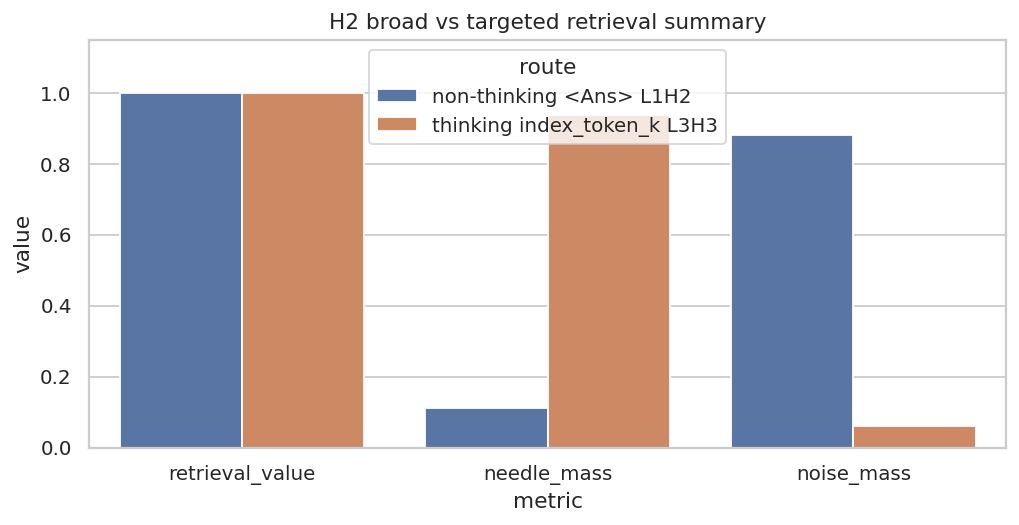

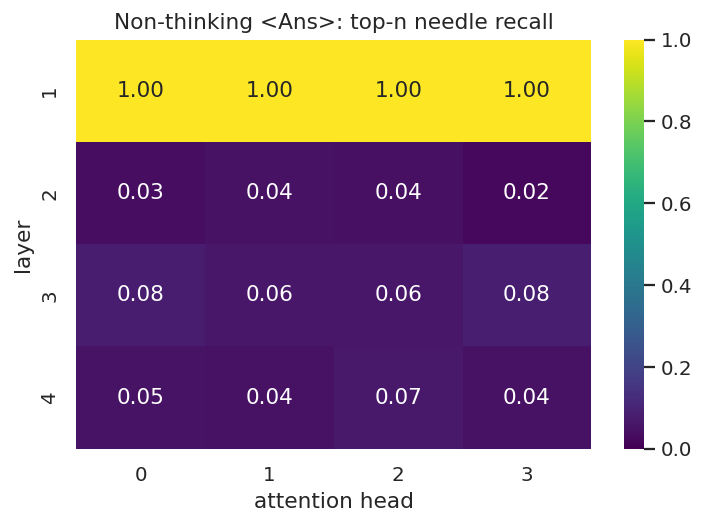

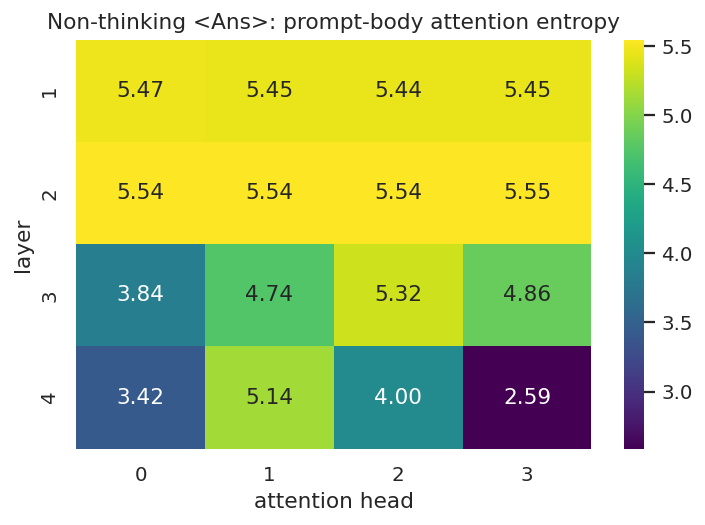

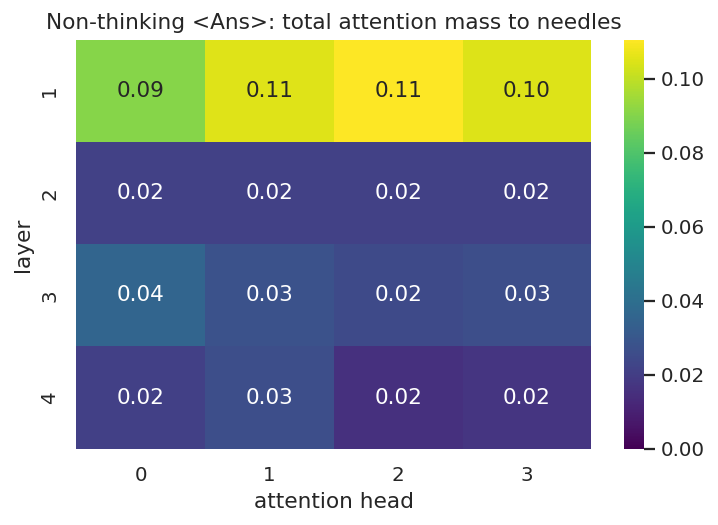

**Interpretation checkpoint.** The best non-thinking head has top-n recall 1.000, but its raw mass to all needles is 0.111. The best thinking head has correct top-1 1.000 with diagonal dominance 0.974. This supports a difference between broad final-answer aggregation and trace-indexed retrieval.

In [58]:
non_head_rank = (
    non_attn_dd
    .groupby(["layer", "head"], as_index=False)
    .agg(
        top_n_retrieval_recall=("top_n_retrieval_recall", "mean"),
        ans_to_all_needles_mass=("ans_to_all_needles_mass", "mean"),
        ans_to_noise_mass=("ans_to_noise_mass", "mean"),
        needle_vs_noise_ratio=("needle_vs_noise_ratio", "mean"),
        attention_entropy_over_prompt_body=("attention_entropy_over_prompt_body", "mean"),
    )
    .sort_values(["top_n_retrieval_recall", "ans_to_all_needles_mass"], ascending=False)
)

display(Markdown("**Best non-thinking <Ans> retrieval heads**"))
display(non_head_rank.head(12))

best_non_head = non_head_rank.iloc[0].to_dict()
BEST_NON_LAYER = int(best_non_head["layer"])
BEST_NON_HEAD = int(best_non_head["head"])

comparison_rows = [
    {
        "route": f"non-thinking <Ans> L{BEST_NON_LAYER}H{BEST_NON_HEAD}",
        "retrieval_metric": "top_n_retrieval_recall",
        "retrieval_value": best_non_head["top_n_retrieval_recall"],
        "needle_mass": best_non_head["ans_to_all_needles_mass"],
        "noise_mass": best_non_head["ans_to_noise_mass"],
        "entropy_or_diagonal": best_non_head["attention_entropy_over_prompt_body"],
        "entropy_or_diagonal_name": "prompt attention entropy",
    },
    {
        "route": f"thinking {BEST_QUERY_ANCHOR} L{BEST_LAYER}H{BEST_HEAD}",
        "retrieval_metric": "correct_top1_rate",
        "retrieval_value": best_thinking_head["correct_top1_rate"],
        "needle_mass": best_thinking_head["needle_attention_mass"],
        "noise_mass": best_thinking_head["noise_attention_mass"],
        "entropy_or_diagonal": best_thinking_head["diagonal_dominance"],
        "entropy_or_diagonal_name": "diagonal dominance",
    },
]
route_comparison = pd.DataFrame(comparison_rows)
display(route_comparison)

plot_df = route_comparison.melt(
    id_vars=["route"],
    value_vars=["retrieval_value", "needle_mass", "noise_mass"],
    var_name="metric",
    value_name="value",
)
plt.figure(figsize=(8, 4.2))
sns.barplot(data=plot_df, x="metric", y="value", hue="route")
plt.ylim(0, max(1.05, float(plot_df["value"].max()) * 1.15))
plt.title("H2 broad vs targeted retrieval summary")
plt.xlabel("metric")
plt.ylabel("value")
plt.tight_layout()
plt.savefig(ANALYSIS_DEEP_DIVE_DIR / "h2_broad_vs_targeted_summary.png", bbox_inches="tight")
plt.show()

for metric, title, filename in [
    ("top_n_retrieval_recall", "Non-thinking <Ans>: top-n needle recall", "h2_nonthinking_topn_recall.png"),
    ("attention_entropy_over_prompt_body", "Non-thinking <Ans>: prompt-body attention entropy", "h2_nonthinking_entropy.png"),
    ("ans_to_all_needles_mass", "Non-thinking <Ans>: total attention mass to needles", "h2_nonthinking_needle_mass.png"),
]:
    mat = non_head_rank.pivot(index="layer", columns="head", values=metric)
    plt.figure(figsize=(5.8, 4.2))
    sns.heatmap(mat, vmin=0 if metric != "attention_entropy_over_prompt_body" else None, vmax=1 if metric == "top_n_retrieval_recall" else None, cmap="viridis", annot=True, fmt=".2f")
    plt.title(title)
    plt.xlabel("attention head")
    plt.ylabel("layer")
    plt.tight_layout()
    plt.savefig(ANALYSIS_DEEP_DIVE_DIR / filename, bbox_inches="tight")
    plt.show()

display(Markdown(
    f"**Interpretation checkpoint.** The best non-thinking head has top-n recall "
    f"{best_non_head['top_n_retrieval_recall']:.3f}, but its raw mass to all needles is "
    f"{best_non_head['ans_to_all_needles_mass']:.3f}. The best thinking head has correct top-1 "
    f"{best_thinking_head['correct_top1_rate']:.3f} with diagonal dominance "
    f"{best_thinking_head['diagonal_dominance']:.3f}. This supports a difference between broad final-answer aggregation and trace-indexed retrieval."
))
        

### Hypothesis 3: the targeted head should matter mechanistically

This cell runs two optional checks:

1. **Checkpoint dynamics.** Recompute the best thinking head's targeted-retrieval metrics at saved checkpoints, then compare them with final-answer accuracy.
2. **Head ablation.** Zero one attention head's value contribution before the output projection during autoregressive thinking generation.

The ablation is deliberately lightweight and local. A large accuracy drop would be strong evidence; no drop would mean the head is diagnostic or redundant rather than individually necessary.
        

deep-dive checkpoint attention:   0%|          | 0/21 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/52 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/52 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/52 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/52 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/52 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/52 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/52 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/52 [00:00<?, ?it/s]

,diagonal_dominance,correct_top1_rate,needle_attention_mass,noise_attention_mass,step,query_anchor,layer,head,thinking_accuracy,high_count_accuracy
0,0.550333,0.308942,0.020678,0.951311,1,index_token_k,3,3,0.000000,0.00000
1,0.919913,0.500097,0.029927,0.963078,500,index_token_k,3,3,0.738889,0.65000
2,0.855464,0.696446,0.391448,0.603800,1000,index_token_k,3,3,0.795139,0.64875
3,0.945353,0.905760,0.847762,0.150449,1500,index_token_k,3,3,0.975833,0.94250
4,0.968576,0.981764,0.914313,0.083821,2000,index_token_k,3,3,0.985139,0.98875
5,0.961633,0.983696,0.934228,0.064290,2500,index_token_k,3,3,0.995278,0.98750
6,0.952579,0.959093,0.944968,0.053019,3000,index_token_k,3,3,0.994167,0.99750
7,0.970373,0.989208,0.882321,0.116263,3500,index_token_k,3,3,0.996250,0.99375
8,0.967710,0.994563,0.901860,0.087281,4000,index_token_k,3,3,0.991389,0.98750
9,0.978643,0.992819,0.921816,0.076366,4500,index_token_k,3,3,0.998750,0.99625


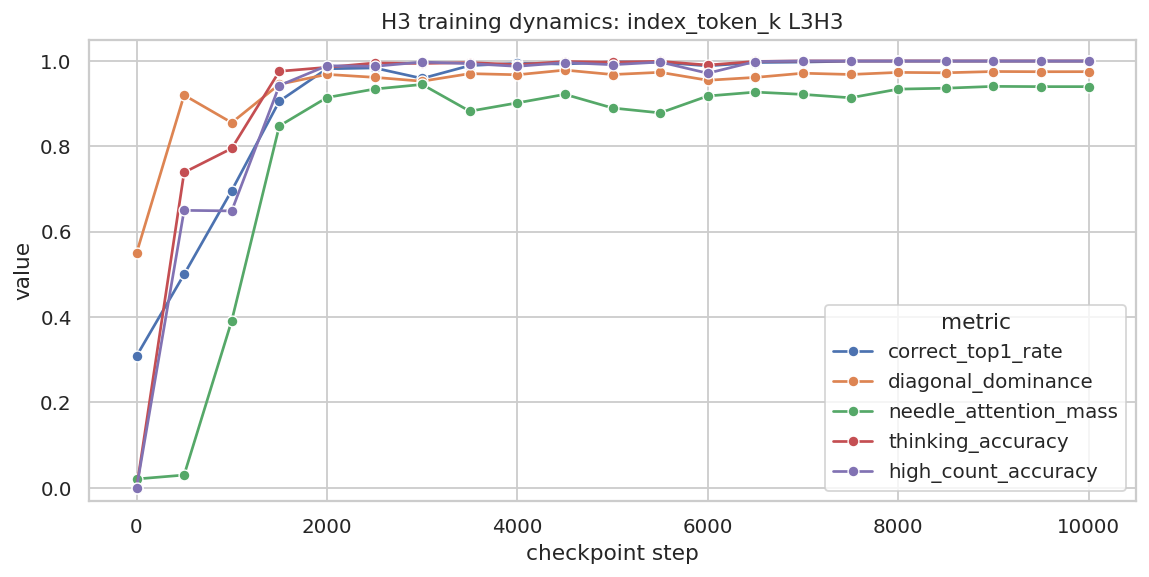

deep-dive head ablation:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/52 [00:00<?, ?it/s]

thinking eval:   0%|          | 0/8 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/52 [00:00<?, ?it/s]

thinking eval:   0%|          | 0/8 [00:00<?, ?it/s]

...

thinking eval:   0%|          | 0/8 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/52 [00:00<?, ?it/s]

thinking eval:   0%|          | 0/8 [00:00<?, ?it/s]

/tmp/ipykernel_2380/609876173.py:287: FutureWarning: Operation between non boolean Series with different indexes will no longer return a boolean result in a future version. Cast both Series to object type to maintain the prior behavior.
  marker_overlap = sum((pd.Series(generated_markers).value_counts() & pd.Series(expected_markers).value_counts()).fillna(0)) if expected_markers or generated_markers else 0
/tmp/ipykernel_2380/609876173.py:287: FutureWarning: Operation between non boolean Series with different indexes will no longer return a boolean result in a future version. Cast both Series to object type to maintain the prior behavior.
  marker_overlap = sum((pd.Series(generated_markers).value_counts() & pd.Series(expected_markers).value_counts()).fillna(0)) if expected_markers or generated_markers else 0
/tmp/ipykernel_2380/609876173.py:287: FutureWarning: Operation between non boolean Series with different indexes will no longer return a boolean result in a future version. Cast bo

,accuracy,invalid_rate,trace_exact_match_rate,trace_marker_recall,trace_index_accuracy,condition,layer,head,n_examples
0,1.000,0.000,1.000,1.000000,1.00000,baseline_no_ablation,NaN,NaN,500
1,0.998,0.000,0.994,0.998333,1.00000,target_index_token_k_L3H3,3.0,3.0,500
2,1.000,0.000,1.000,1.000000,1.00000,same_layer_control_L3H0,3.0,0.0,500
3,0.982,0.004,0.852,0.912060,0.99745,early_control_L1H0,1.0,0.0,500


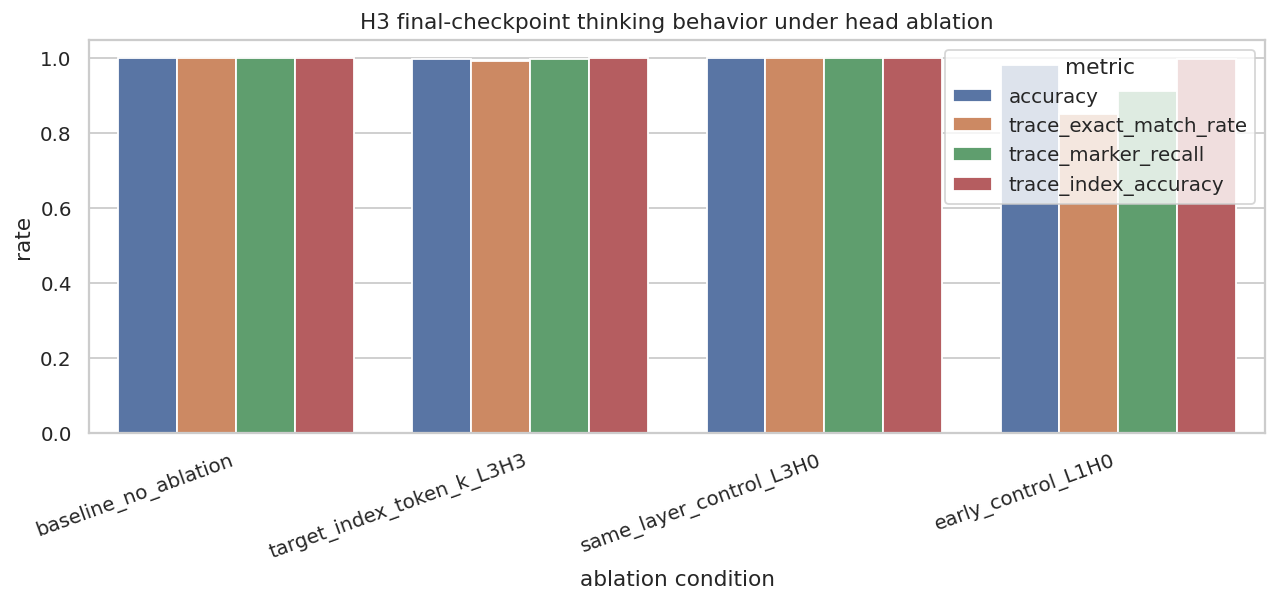

Deep-dive outputs saved under `runs/v2_marker_trace_seed1234_main/targeted_retrieval_deep_dive`.

In [59]:
def checkpoint_step_dirs(checkpoint_dir: Path) -> list[tuple[int, Path]]:
    out = []
    for path in checkpoint_dir.glob("step_*"):
        try:
            step = int(path.name.split("_")[1])
        except Exception:
            continue
        if (path / "thinking" / "config.json").exists():
            out.append((step, path))
    return sorted(out)


def mean_selected_thinking_head_metrics(
    model: GPT2LMHeadModel,
    examples: list[BaseExample],
    query_anchor: str,
    layer: int,
    head: int,
    vocab: Vocab,
    cfg: dict[str, Any],
) -> dict[str, float]:
    model.eval()
    diag_vals = []
    top1_vals = []
    needle_vals = []
    noise_vals = []
    layer_idx = layer - 1
    for ex in examples:
        rendered = render_example(ex, "thinking", vocab)
        input_ids = torch.tensor([rendered["input_ids"]], dtype=torch.long, device=cfg["device"])
        attention_mask = torch.ones_like(input_ids)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, output_attentions=True)
        weights_all = outputs.attentions[layer_idx][0, head].detach().float().cpu().numpy()
        prompt_indices = list(range(rendered["anchors"]["prompt_start"], rendered["anchors"]["prompt_end_exclusive"]))
        needle_indices = [1 + pos for pos in ex.needle_positions]
        noise_indices = [idx for idx in prompt_indices if idx not in set(needle_indices)]
        query_positions = rendered["anchors"][{
            "index_token_k": "index_positions",
            "marker_token_k": "marker_positions",
            "pre_index_k": "pre_index_positions",
        }[query_anchor]]
        A = np.zeros((ex.count, ex.count), dtype=np.float32)
        top1 = []
        needle_mass = 0.0
        noise_mass = 0.0
        for k_idx, q in enumerate(query_positions):
            weights = weights_all[q, :]
            A[k_idx] = weights[needle_indices]
            top1.append(int(np.argmax(weights[needle_indices]) == k_idx))
            needle_mass += float(weights[needle_indices].sum())
            noise_mass += float(weights[noise_indices].sum())
        diag = float(np.diag(A).mean())
        off = float((A.sum() - np.diag(A).sum()) / max(ex.count * (ex.count - 1), 1))
        diag_vals.append(diag / (diag + off + 1e-12))
        top1_vals.append(float(np.mean(top1)))
        needle_vals.append(needle_mass / ex.count)
        noise_vals.append(noise_mass / ex.count)
    return {
        "diagonal_dominance": float(np.mean(diag_vals)),
        "correct_top1_rate": float(np.mean(top1_vals)),
        "needle_attention_mass": float(np.mean(needle_vals)),
        "noise_attention_mass": float(np.mean(noise_vals)),
    }


if RUN_DEEP_DIVE_DYNAMICS:
    dynamics_path = ANALYSIS_DEEP_DIVE_DIR / f"h3_dynamics_{BEST_QUERY_ANCHOR}_L{BEST_LAYER}H{BEST_HEAD}.csv"
    if dynamics_path.exists():
        dynamics = pd.read_csv(dynamics_path)
    else:
        dyn_examples = balanced_examples(ANALYSIS_CFG["seq_len"], DEEP_DIVE_ATTENTION_EXAMPLES_PER_COUNT, ANALYSIS_CFG["seed"] + 909)
        dyn_rows = []
        for step, ckpt_path in tqdm(checkpoint_step_dirs(ANALYSIS_CHECKPOINT_DIR), desc="deep-dive checkpoint attention"):
            model = GPT2LMHeadModel.from_pretrained(ckpt_path / "thinking", attn_implementation="eager").to(ANALYSIS_CFG["device"])
            metrics = mean_selected_thinking_head_metrics(model, dyn_examples, BEST_QUERY_ANCHOR, BEST_LAYER, BEST_HEAD, vocab, ANALYSIS_CFG)
            metrics.update({"step": step, "query_anchor": BEST_QUERY_ANCHOR, "layer": BEST_LAYER, "head": BEST_HEAD})
            dyn_rows.append(metrics)
            del model
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
        dynamics = pd.DataFrame(dyn_rows)
        dynamics.to_csv(dynamics_path, index=False)

    acc_curve = (
        bin_eval_dd[bin_eval_dd["model_type"] == "thinking"]
        .groupby("step", as_index=False)
        .agg(thinking_accuracy=("accuracy", "mean"), high_count_accuracy=("accuracy", lambda s: s[bin_eval_dd.loc[s.index, "count_bin"].eq("high")].mean()))
    )
    dynamics_plot = dynamics.merge(acc_curve, on="step", how="left")
    display(dynamics_plot)

    plot_cols = ["correct_top1_rate", "diagonal_dominance", "needle_attention_mass", "thinking_accuracy", "high_count_accuracy"]
    plot_long = dynamics_plot.melt(id_vars=["step"], value_vars=[c for c in plot_cols if c in dynamics_plot], var_name="metric", value_name="value")
    plt.figure(figsize=(9, 4.6))
    sns.lineplot(data=plot_long, x="step", y="value", hue="metric", marker="o")
    plt.ylim(-0.03, 1.05)
    plt.title(f"H3 training dynamics: {BEST_QUERY_ANCHOR} L{BEST_LAYER}H{BEST_HEAD}")
    plt.xlabel("checkpoint step")
    plt.ylabel("value")
    plt.tight_layout()
    plt.savefig(ANALYSIS_DEEP_DIVE_DIR / "h3_targeted_head_training_dynamics.png", bbox_inches="tight")
    plt.show()


from contextlib import contextmanager


@contextmanager
def ablate_gpt2_attention_head(model: GPT2LMHeadModel, layer: int, head: int):
    attn = model.transformer.h[layer - 1].attn
    head_dim = model.config.n_embd // model.config.n_head
    start = head * head_dim
    stop = start + head_dim

    def pre_hook(module, inputs):
        x = inputs[0].clone()
        x[..., start:stop] = 0.0
        return (x,) + tuple(inputs[1:])

    handle = attn.c_proj.register_forward_pre_hook(pre_hook)
    try:
        yield
    finally:
        handle.remove()


def summarize_thinking_predictions(rows: list[dict[str, Any]]) -> dict[str, float]:
    df = pd.DataFrame(rows)
    correct = df["pred_count"].fillna(-999).astype(int).eq(df["count"].astype(int))
    return {
        "accuracy": float(correct.mean()),
        "invalid_rate": float(df["invalid"].mean()),
        "trace_exact_match_rate": float(df["trace_exact_match"].mean()),
        "trace_marker_recall": float(df["trace_marker_recall"].mean()),
        "trace_index_accuracy": float(df["trace_index_accuracy"].mean()),
    }


if RUN_DEEP_DIVE_HEAD_ABLATION:
    ablation_path = ANALYSIS_DEEP_DIVE_DIR / "h3_thinking_head_ablation.csv"
    if ablation_path.exists():
        ablation_df = pd.read_csv(ablation_path)
    else:
        ablation_examples = balanced_examples(ANALYSIS_CFG["seq_len"], DEEP_DIVE_ABLATION_EXAMPLES_PER_COUNT, ANALYSIS_CFG["seed"] + 1009)
        final_thinking_path = ANALYSIS_CHECKPOINT_DIR / "final" / "thinking"
        if not final_thinking_path.exists():
            final_steps = checkpoint_step_dirs(ANALYSIS_CHECKPOINT_DIR)
            final_thinking_path = final_steps[-1][1] / "thinking"
        ablation_heads = [
            ("baseline_no_ablation", None, None),
            (f"target_{BEST_QUERY_ANCHOR}_L{BEST_LAYER}H{BEST_HEAD}", BEST_LAYER, BEST_HEAD),
            (f"same_layer_control_L{BEST_LAYER}H{(BEST_HEAD + 1) % ANALYSIS_CFG['n_head']}", BEST_LAYER, (BEST_HEAD + 1) % ANALYSIS_CFG["n_head"]),
            ("early_control_L1H0", 1, 0),
        ]
        rows = []
        for name, layer, head in tqdm(ablation_heads, desc="deep-dive head ablation"):
            model = GPT2LMHeadModel.from_pretrained(final_thinking_path).to(ANALYSIS_CFG["device"])
            if layer is None:
                preds = predict_thinking(model, ablation_examples, vocab, ANALYSIS_CFG, batch_size=64)
            else:
                with ablate_gpt2_attention_head(model, int(layer), int(head)):
                    preds = predict_thinking(model, ablation_examples, vocab, ANALYSIS_CFG, batch_size=64)
            metrics = summarize_thinking_predictions(preds)
            metrics.update({"condition": name, "layer": layer, "head": head, "n_examples": len(ablation_examples)})
            rows.append(metrics)
            del model
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
        ablation_df = pd.DataFrame(rows)
        ablation_df.to_csv(ablation_path, index=False)

    display(ablation_df)
    plot_long = ablation_df.melt(
        id_vars=["condition"],
        value_vars=["accuracy", "trace_exact_match_rate", "trace_marker_recall", "trace_index_accuracy"],
        var_name="metric",
        value_name="value",
    )
    plt.figure(figsize=(10, 4.8))
    sns.barplot(data=plot_long, x="condition", y="value", hue="metric")
    plt.ylim(0, 1.05)
    plt.xticks(rotation=20, ha="right")
    plt.title("H3 final-checkpoint thinking behavior under head ablation")
    plt.xlabel("ablation condition")
    plt.ylabel("rate")
    plt.tight_layout()
    plt.savefig(ANALYSIS_DEEP_DIVE_DIR / "h3_thinking_head_ablation.png", bbox_inches="tight")
    plt.show()

display(Markdown(f"Deep-dive outputs saved under `{ANALYSIS_DEEP_DIVE_DIR}`."))
        

## Save Result Bundle

In Colab, this saves to:

`/content/drive/MyDrive/Colab_Notebooks/CoT_Counting/Synthetic_CoT_NiaH_Count/colab_results/`
        

In [60]:
SAVE_RESULTS = True
DRIVE_RESULTS_ROOT = Path("/content/drive/MyDrive/Colab_Notebooks/CoT_Counting/Synthetic_CoT_NiaH_Count/colab_results")
LOCAL_RESULTS_ROOT = Path("colab_results")

if SAVE_RESULTS:
    if IN_COLAB:
        from google.colab import drive

        ensure_google_drive_mounted()
        results_root = DRIVE_RESULTS_ROOT
    else:
        results_root = LOCAL_RESULTS_ROOT
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    bundle_dir = results_root / f"v2_marker_trace_{PRESET}_seed{cfg['seed']}_{timestamp}"
    bundle_dir.mkdir(parents=True, exist_ok=True)
    shutil.copytree(RUN_DIR, bundle_dir / "run", dirs_exist_ok=True)
    nb_src = Path("notebooks/Trace_Count_v2_Colab.ipynb")
    if nb_src.exists():
        (bundle_dir / "notebooks").mkdir(exist_ok=True)
        shutil.copy2(nb_src, bundle_dir / "notebooks" / nb_src.name)
    with (bundle_dir / "manifest.json").open("w", encoding="utf-8") as f:
        json.dump({"preset": PRESET, "config": cfg, "run_dir": str(RUN_DIR), "saved_at": timestamp}, f, indent=2)
    print("Saved:", bundle_dir)
        

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved: /content/drive/MyDrive/Colab_Notebooks/CoT_Counting/Synthetic_CoT_NiaH_Count/colab_results/v2_marker_trace_main_seed1234_20260706_215757


## Optional GitHub Push

This cell is disabled by default. It commits the notebook and supporting files, not large run outputs.
        

In [61]:
PUSH_TO_GITHUB = False
COMMIT_MESSAGE = "Rewrite Trace Count v2 marker-trace notebook"

if PUSH_TO_GITHUB:
    subprocess.run(["git", "status", "--short"], check=False)
    subprocess.run(
        [
            "git",
            "add",
            "notebooks/Trace_Count_v2_Colab.ipynb",
            "notebooks/pipeline_v2_codex_prompt.md",
            "scripts/build_v2_notebook.py",
            "README.md",
        ],
        check=True,
    )
    subprocess.run(["git", "commit", "-m", COMMIT_MESSAGE], check=False)
    subprocess.run(["git", "push"], check=True)
else:
    print("PUSH_TO_GITHUB is False; no git commands were run.")
        

PUSH_TO_GITHUB is False; no git commands were run.
